# Import & Load Data

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('.')

from functions.fn_clean import (
    standardize_column_names,
    drop_structural_columns,
    fix_column_types,
    handle_intentional_nulls,
    impute_column,
    cap_outliers_iqr,
    transform_skewed_column,
    bin_rare_categories,
    merge_tables,
)
from functions.fn_explore import (
    summarize_dataframe,
    describe_column,
    rank_features_for_target,
    get_correlation_matrix,
    test_relationship,
    compute_target_rate_by_category,
)
from functions.fn_plot import (
    plot_missing_heatmap,
    plot_distributions_all,
    plot_distribution,
    plot_target_rate,
    plot_scatter,
    plot_boxplot,
    plot_correlation_heatmap,
    plot_bivariate_summary,
)

## Load Raw Data

In [32]:
# Load both tables raw — no cleaning yet
posts     = pd.read_csv('data/social_media_posts.csv')
donations = pd.read_csv('data/donations.csv')

print(f"posts shape:     {posts.shape}")
print(f"donations shape: {donations.shape}")
posts.head()

posts shape:     (812, 39)
donations shape: (420, 13)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62,0,0.00,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172,2,8351.49,916,NaN,NaN,NaN,NaN


# Univariate Analysis

## First Look: Structure and Types

In [33]:
# What do we actually have? Types, shape, first few rows.
# Run this before anything else — it tells you what you're dealing with.
print(posts.dtypes)
print()
print(posts.info())

post_id                           int64
platform                            str
platform_post_id                    str
post_url                            str
created_at                          str
day_of_week                         str
post_hour                         int64
post_type                           str
media_type                          str
caption                             str
hashtags                            str
num_hashtags                      int64
mentions_count                    int64
has_call_to_action                 bool
call_to_action_type                 str
content_topic                       str
sentiment_tone                      str
caption_length                    int64
features_resident_story            bool
campaign_name                       str
is_boosted                         bool
boost_budget_php                float64
impressions                       int64
reach                             int64
likes                             int64


Full Univariate Summary

In [34]:
# summarize_dataframe() scans every column and returns two tables:
# one for numeric columns (with skew, range, mean) and one for categoricals
# (with mode and top 5 values). This is your map of the dataset.
#
# Things to look for:
#   - missing_pct > 0: is this structural (intentional null) or a data quality problem?
#   - skew > 1 or < -1: will need transform_skewed_column()
#   - unique == n_rows: probably an ID column, drop it
#   - unique == 1: constant column, useless for modeling, drop it

num_df, cat_df = summarize_dataframe(posts)


  NUMERIC COLUMNS (23)
                                dtype  count  missing  missing_pct         min          max          mean        median           std     skew      kurt
column                                                                                                                                                  
post_id                         int64    812        0         0.00      1.0000       812.00  4.065000e+02  4.065000e+02  2.345485e+02   0.0000   -1.2000
post_hour                       int64    812        0         0.00      0.0000        23.00  1.269090e+01  1.300000e+01  6.296600e+00  -0.2558   -0.9638
num_hashtags                    int64    812        0         0.00      0.0000         5.00  2.046800e+00  2.000000e+00  1.414300e+00   0.1163   -0.9047
mentions_count                  int64    812        0         0.00      0.0000         3.00  6.121000e-01  0.000000e+00  8.535000e-01   1.2643    0.6872
caption_length                  int64    812        0     

## Missing Value Map

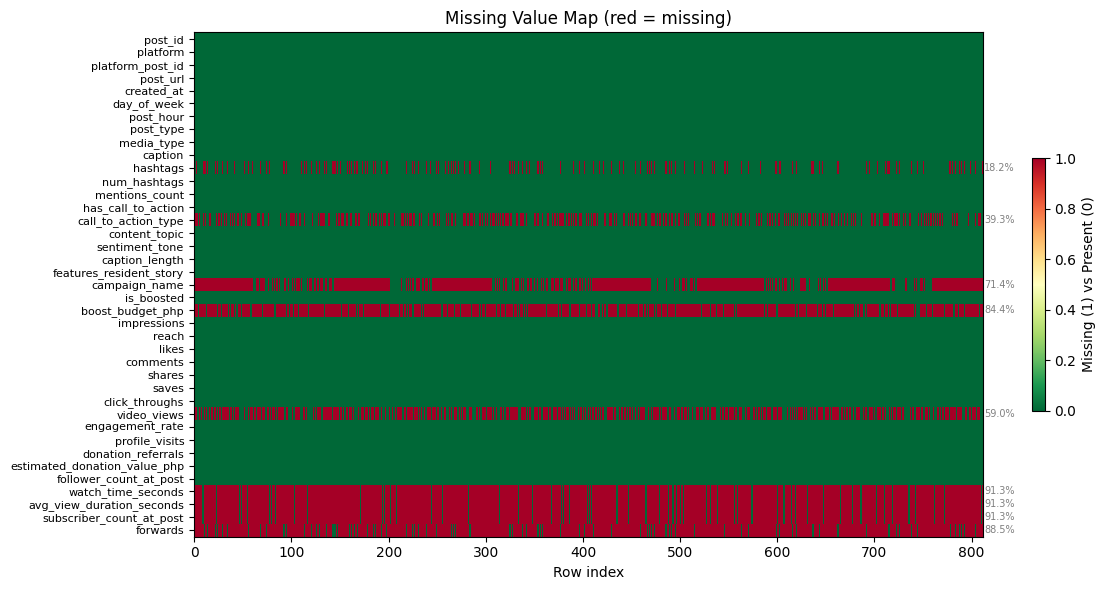

In [35]:
# Visual map of where nulls live. Red = missing, green = present.
# In social_media_posts, you should see clear vertical bands of missingness
# for columns that are intentionally null for certain post types:
#   - video_views: null for non-Video/Reel posts
#   - watch_time_seconds: null for non-YouTube posts
#   - avg_view_duration_seconds: null for non-YouTube posts
#   - subscriber_count_at_post: null for non-YouTube posts
#   - boost_budget_php: null when is_boosted is False
#   - forwards: null for non-WhatsApp posts
#   - call_to_action_type: null when has_call_to_action is False
#
# These are NOT data quality problems. They are structural.
# We will handle them with handle_intentional_nulls(), not impute_column().

plot_missing_heatmap(posts)

## Quick Visual Sweep of All Distributions

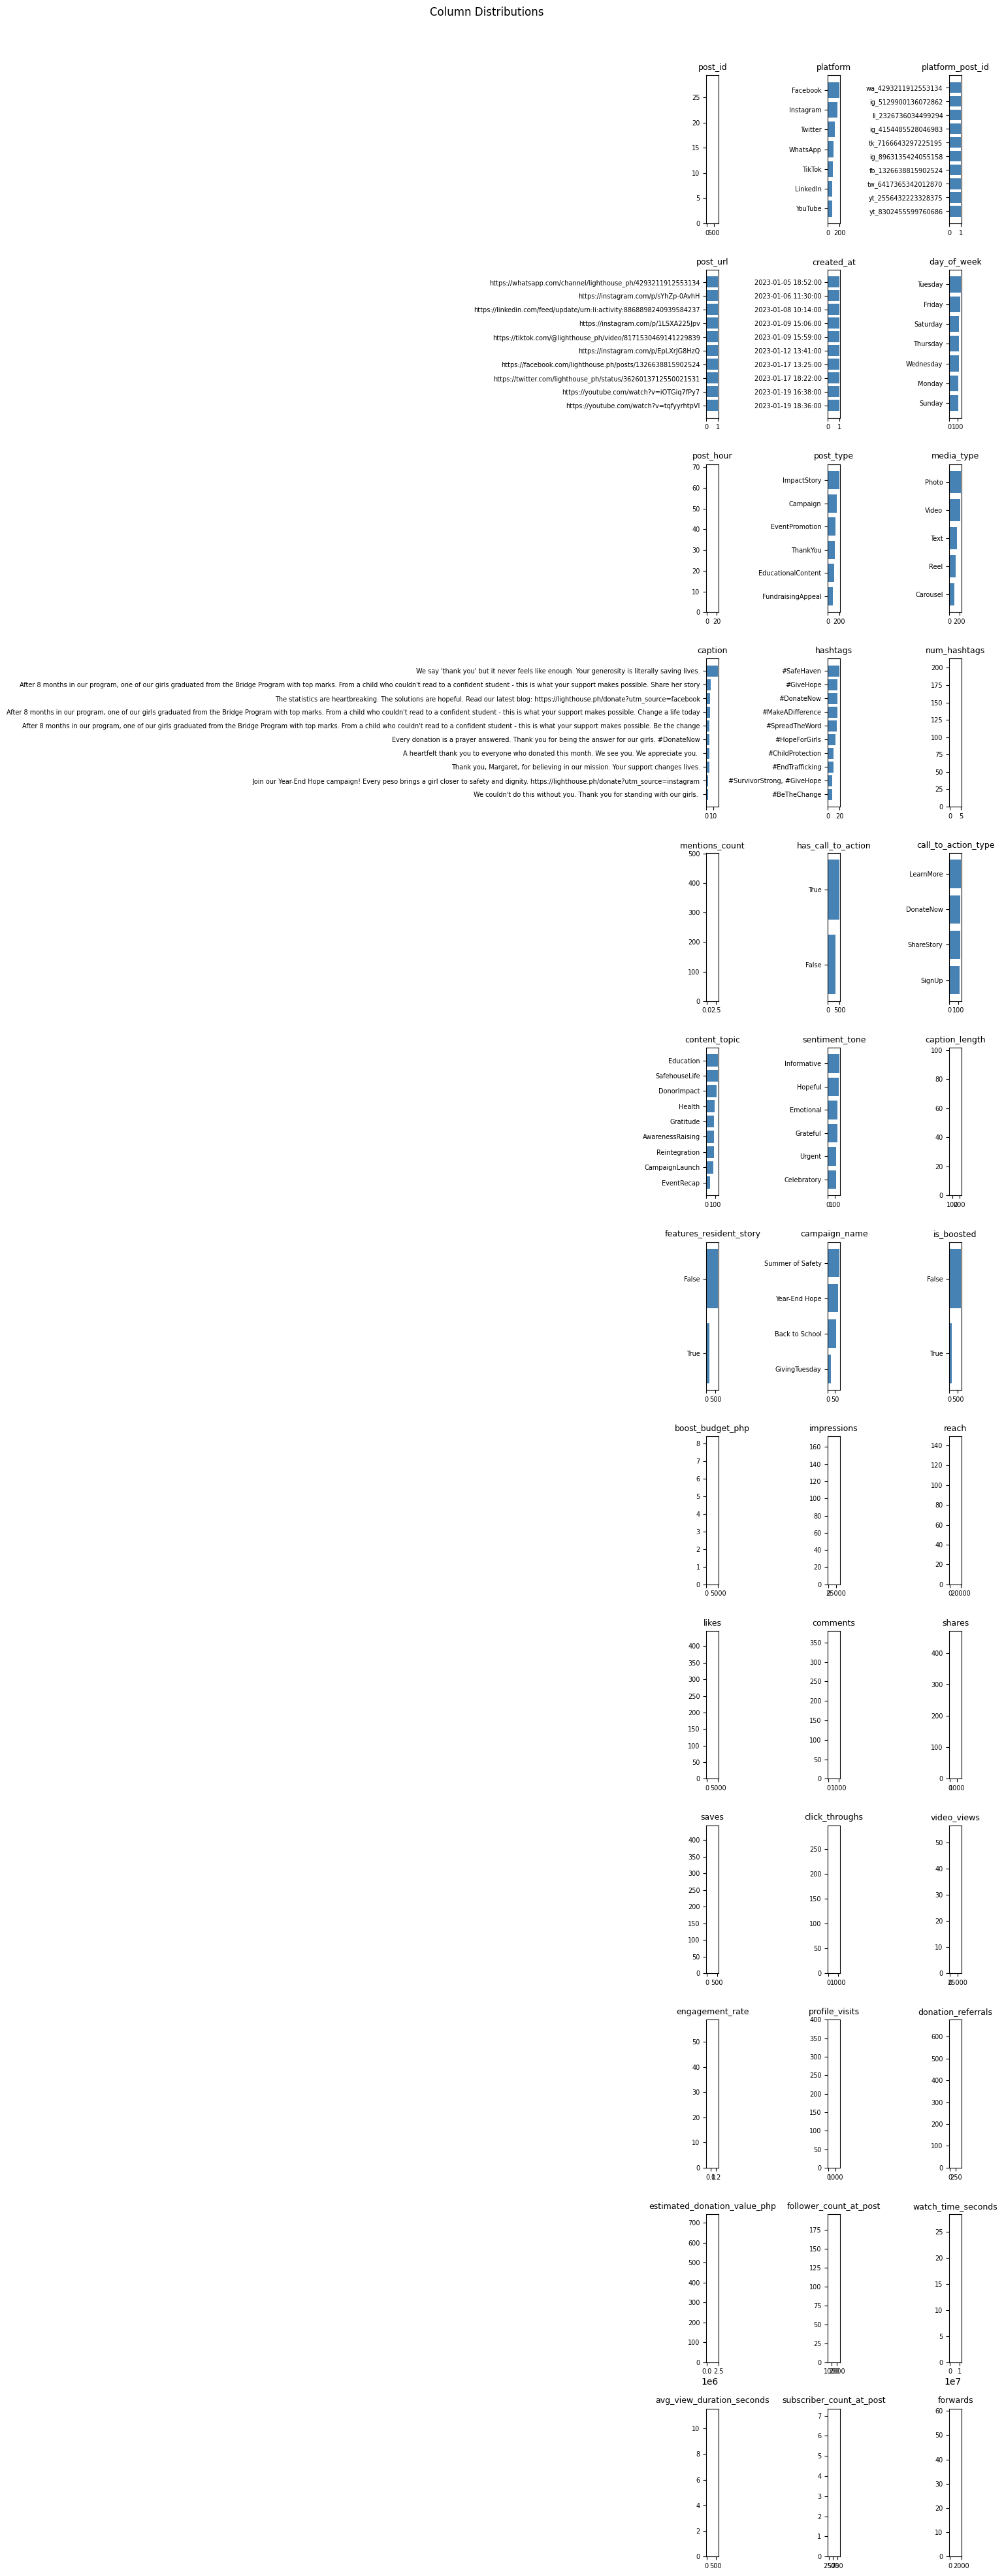

In [36]:
# Look at every column's distribution at once.
# You're scanning for: extreme skew, unexpected value ranges,
# columns with only 2-3 unique values, anything that looks wrong.
# This takes ~30 seconds to render for a wide table.

plot_distributions_all(posts)

## Drop Structural Columns

In [37]:
# Drop columns that should never enter any model:
#   post_id          — primary key, no signal
#   platform_post_id — unique platform-native ID, no signal
#   post_url         — unique URL, no signal
#   caption          — free text; we'll use caption_length instead
#   hashtags         — free text; we'll use num_hashtags instead
#
# We keep created_at for now so we can extract date features from it,
# then we'll drop it after parsing.

posts = drop_structural_columns(posts, [
    'post_id',
    'platform_post_id',
    'post_url',
    'caption',
    'hashtags',
])

[drop_structural_columns] Dropped 5 columns: ['post_id', 'platform_post_id', 'post_url', 'caption', 'hashtags']


## Fix Column Types

In [38]:
# Scan all string columns and convert them to numeric or datetime if possible.
# created_at should convert to datetime automatically.
# Boolean columns stored as strings ("True"/"False") will convert to numeric.

posts = fix_column_types(posts)
posts.dtypes

platform                            str
created_at                          str
day_of_week                         str
post_hour                         int64
post_type                           str
media_type                          str
num_hashtags                      int64
mentions_count                    int64
has_call_to_action                 bool
call_to_action_type                 str
content_topic                       str
sentiment_tone                      str
caption_length                    int64
features_resident_story            bool
campaign_name                       str
is_boosted                         bool
boost_budget_php                float64
impressions                       int64
reach                             int64
likes                             int64
comments                          int64
shares                            int64
saves                             int64
click_throughs                    int64
video_views                     float64


## Parse created_at into Useful Features

In [39]:
# created_at gives us temporal information the model can use.
# BUT: social_media_posts already has day_of_week and post_hour,
# so we only need to extract month (seasonality) and is_weekend.
# We already have the hour and day of week covered.
#
# After extracting, we drop created_at — a raw datetime can't go into a model.

posts['created_at'] = pd.to_datetime(posts['created_at'], errors='coerce')
posts['post_month']      = posts['created_at'].dt.month
posts['post_is_weekend'] = posts['created_at'].dt.dayofweek.ge(5).astype(int)
posts = posts.drop(columns=['created_at'])

print("Added: post_month, post_is_weekend")

Added: post_month, post_is_weekend


## Handle Intentional Nulls

In [40]:
# Fill intentional nulls with meaningful sentinels BEFORE any modeling.
# These are not missing data — they are nulls by design:
#
#   video_views / watch_time_seconds / avg_view_duration_seconds /
#   subscriber_count_at_post → 0 for non-video/non-YouTube posts
#
#   boost_budget_php → 0 when is_boosted is False
#   forwards         → 0 for non-WhatsApp posts
#   call_to_action_type → 'None' when has_call_to_action is False
#
# This is a deliberate modeling decision: a post with no video has
# 0 video views, not an unknown number of video views.

posts = handle_intentional_nulls(posts, {
    'video_views':               0,
    'watch_time_seconds':        0,
    'avg_view_duration_seconds': 0,
    'subscriber_count_at_post':  0,
    'boost_budget_php':          0,
    'forwards':                  0,
    'call_to_action_type':       'None',
})

# Confirm no more nulls except possibly campaign_name (legitimately optional)
print(posts.isnull().sum()[posts.isnull().sum() > 0])

[handle_intentional_nulls] 'video_views' — filled 479 nulls with 0.
[handle_intentional_nulls] 'watch_time_seconds' — filled 741 nulls with 0.
[handle_intentional_nulls] 'avg_view_duration_seconds' — filled 741 nulls with 0.
[handle_intentional_nulls] 'subscriber_count_at_post' — filled 741 nulls with 0.
[handle_intentional_nulls] 'boost_budget_php' — filled 685 nulls with 0.
[handle_intentional_nulls] 'forwards' — filled 719 nulls with 0.
[handle_intentional_nulls] 'call_to_action_type' — filled 319 nulls with 'None'.
campaign_name    580
dtype: int64


## Check campaign_name

In [41]:
# campaign_name is null when the post is not tied to a campaign — that's fine.
# We handle it by converting null → 'None' (same logic as call_to_action_type).
# This way the model can learn whether being campaign-linked matters.

print(f"campaign_name null count: {posts['campaign_name'].isnull().sum()}")
print(f"Value counts:\n{posts['campaign_name'].value_counts(dropna=False).head(10)}")

campaign_name null count: 580
Value counts:
campaign_name
NaN                 580
Summer of Safety     81
Year-End Hope        72
Back to School       57
GivingTuesday        22
Name: count, dtype: int64


In [42]:
posts['campaign_name'] = posts['campaign_name'].fillna('None')

## Impute Any Remaining Structural Nulls

In [43]:
# After intentional nulls are handled, check what's left.
# Any remaining nulls are genuine missing values.
# Run summarize_dataframe again to see the current state.

remaining_nulls = posts.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(remaining_nulls if len(remaining_nulls) > 0 else "No remaining nulls.")

No remaining nulls.


In [44]:
# If there are any remaining numeric nulls, impute with median.
# If there are remaining categorical nulls, impute with mode.
# Run this for each column that still has nulls — adjust as needed.
#
# Example (run only if the column has nulls):
# posts = impute_column(posts, 'some_column')

## Check for and bin Rare Categories as needed

In [45]:
# Look at the value counts for every categorical column.
# Categories with fewer than ~5% of rows are noise for the model —
# it can't learn meaningful patterns from 3 examples.
# bin_rare_categories() collapses them into 'Other'.
#
# Check each one before deciding whether to bin:

for col in ['platform', 'post_type', 'media_type', 'call_to_action_type',
            'content_topic', 'sentiment_tone', 'campaign_name', 'day_of_week']:
    counts = posts[col].value_counts(normalize=True).round(3)
    print(f"\n{col}:\n{counts.to_string()}")


platform:
platform
Facebook     0.245
Instagram    0.202
Twitter      0.144
WhatsApp     0.115
TikTok       0.110
LinkedIn     0.097
YouTube      0.087

post_type:
post_type
ImpactStory           0.250
Campaign              0.192
EventPromotion        0.161
ThankYou              0.145
EducationalContent    0.140
FundraisingAppeal     0.111

media_type:
media_type
Photo       0.280
Video       0.261
Text        0.190
Reel        0.149
Carousel    0.121

call_to_action_type:
call_to_action_type
None          0.393
LearnMore     0.161
DonateNow     0.151
ShareStory    0.149
SignUp        0.145

content_topic:
content_topic
Education           0.155
SafehouseLife       0.150
DonorImpact         0.139
Health              0.110
Gratitude           0.102
AwarenessRaising    0.102
Reintegration       0.097
CampaignLaunch      0.092
EventRecap          0.052

sentiment_tone:
sentiment_tone
Informative    0.200
Hopeful        0.183
Emotional      0.170
Grateful       0.160
Urgent         0.148


In [46]:
# Based on Cell 13, bin any categories below 5% representation.
# campaign_name is likely to need this — there may be many small campaigns.
# Adjust the list based on what you see above.

posts = bin_rare_categories(posts, 'campaign_name',    threshold=0.05)
posts = bin_rare_categories(posts, 'call_to_action_type', threshold=0.05)

# Re-check after binning
print(posts['campaign_name'].value_counts())

[bin_rare_categories] 'campaign_name' — collapsed 1 rare categories into 'Other': ['GivingTuesday']
[bin_rare_categories] 'call_to_action_type' — no rare categories at 5.0% threshold.
campaign_name
None                580
Summer of Safety     81
Year-End Hope        72
Back to School       57
Other                22
Name: count, dtype: int64


## Inspect Skewed Numeric Columns


────────────────────────────────────────────────────
  Column  : boost_budget_php
  Type    : float64  |  Unique: 128
  Count   : 812  |  Missing: 0 (0.0%)
  Range   : 0.0 → 4966.98
  Mean    : 380.084  |  Median: 0.0  |  Std: 1037.743
  Skew    : 2.8461  |  Kurt: 7.1073
  ⚠️  High skew (2.85) — consider transform_skewed_column()
────────────────────────────────────────────────────


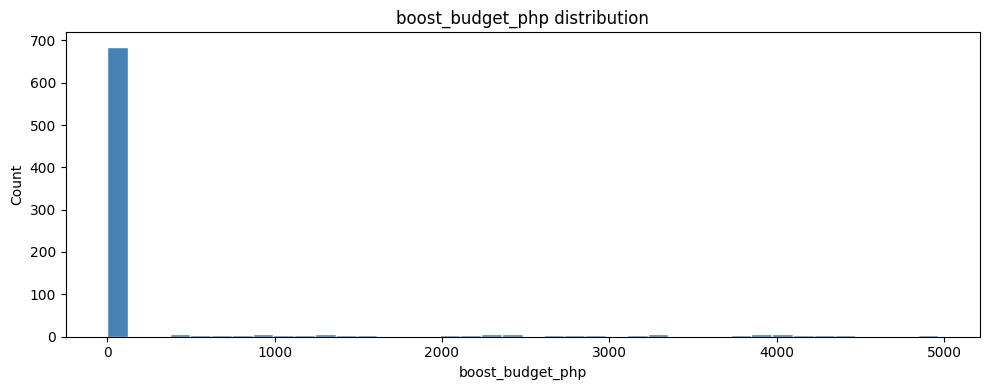


────────────────────────────────────────────────────
  Column  : estimated_donation_value_php
  Type    : float64  |  Unique: 523
  Count   : 812  |  Missing: 0 (0.0%)
  Range   : 0.0 → 2402435.96
  Mean    : 39772.0937  |  Median: 4556.955  |  Std: 124081.1227
  Skew    : 10.8362  |  Kurt: 175.1037
  ⚠️  High skew (10.84) — consider transform_skewed_column()
────────────────────────────────────────────────────


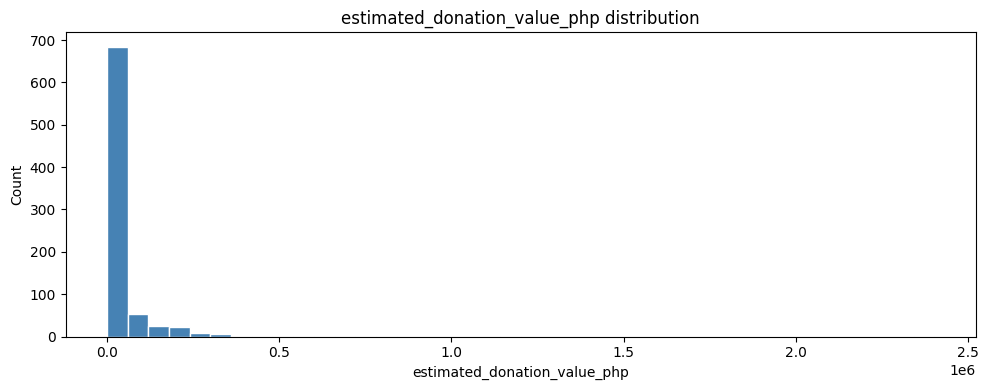


────────────────────────────────────────────────────
  Column  : donation_referrals
  Type    : int64  |  Unique: 95
  Count   : 812  |  Missing: 0 (0.0%)
  Range   : 0 → 458
  Mean    : 12.7956  |  Median: 2.0  |  Std: 31.2617
  Skew    : 6.2177  |  Kurt: 61.9748
  ⚠️  High skew (6.22) — consider transform_skewed_column()
────────────────────────────────────────────────────


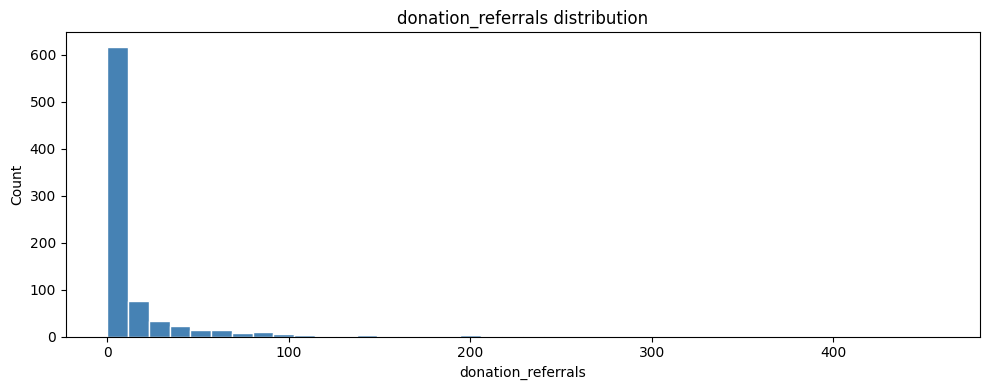


────────────────────────────────────────────────────
  Column  : impressions
  Type    : int64  |  Unique: 790
  Count   : 812  |  Missing: 0 (0.0%)
  Range   : 91 → 35920
  Mean    : 5701.8411  |  Median: 3275.5  |  Std: 6449.2371
  Skew    : 2.13  |  Kurt: 4.8245
  ⚠️  High skew (2.13) — consider transform_skewed_column()
────────────────────────────────────────────────────


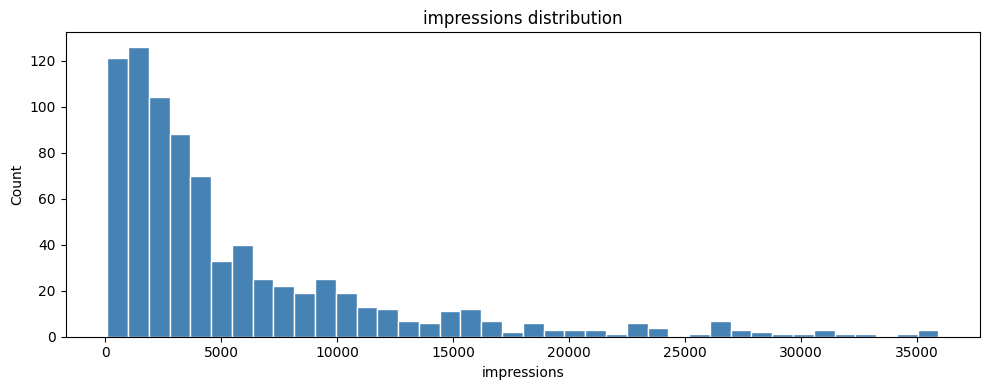


────────────────────────────────────────────────────
  Column  : reach
  Type    : int64  |  Unique: 754
  Count   : 812  |  Missing: 0 (0.0%)
  Range   : 66 → 20000
  Mean    : 3683.6121  |  Median: 2144.5  |  Std: 4157.1834
  Skew    : 2.1056  |  Kurt: 4.5777
  ⚠️  High skew (2.11) — consider transform_skewed_column()
────────────────────────────────────────────────────


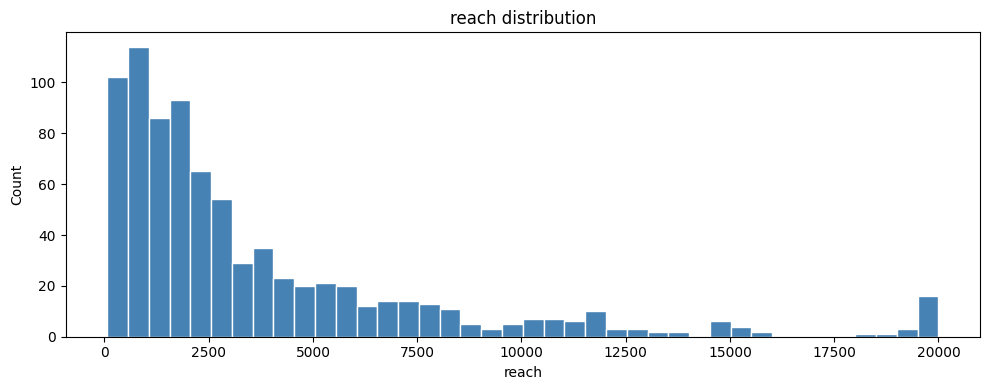

In [47]:
# From the num_df summary in Cell 4, find columns with |skew| > 1.
# These are candidates for transform_skewed_column().
# Plot them first so you can see what you're dealing with.
#
# Expected high-skew columns for social_media_posts:
#   boost_budget_php           — most posts have 0, a few have large values
#   estimated_donation_value_php — same pattern
#   donation_referrals         — most posts have 0, rare posts drive donations
#   impressions / reach        — boosted posts can have 10x more reach

for col in ['boost_budget_php', 'estimated_donation_value_php',
            'donation_referrals', 'impressions', 'reach']:
    describe_column(posts, col)
    plot_distribution(posts, col)

### Cap Outliers and Transform Skew

In [48]:
# Order matters: cap outliers FIRST, then transform.
# Capping prevents a single extreme post from dominating the transformation.
#
# For engagement_rate and donation_referrals: these are our TARGET variables
# for the pipelines. Don't transform targets — the model needs to predict
# in the original scale. Cap outliers only.
#
# For INPUT features (boost_budget_php, impressions, etc.):
# cap + transform both.

# Cap outliers on numeric feature columns (not targets)
posts = cap_outliers_iqr(posts, 'boost_budget_php')
posts = cap_outliers_iqr(posts, 'impressions')
posts = cap_outliers_iqr(posts, 'reach')
posts = cap_outliers_iqr(posts, 'follower_count_at_post')

# Transform skewed feature columns
posts = transform_skewed_column(posts, 'boost_budget_php')
posts = transform_skewed_column(posts, 'impressions')
posts = transform_skewed_column(posts, 'reach')

[cap_outliers_iqr] 'boost_budget_php' — capped 127 outliers (fences: [0.00, 0.00]).
[cap_outliers_iqr] 'impressions' — capped 61 outliers (fences: [-7207.12, 16091.88]).
[cap_outliers_iqr] 'reach' — capped 66 outliers (fences: [-4639.12, 10413.88]).
[cap_outliers_iqr] 'follower_count_at_post' — capped 0 outliers (fences: [-459.50, 3208.50]).
[transform_skewed_column] 'boost_budget_php' skew=0.000 — below threshold, no transform.
[transform_skewed_column] 'impressions' — yeo-johnson applied (skew: 1.159 → 0.045).
[transform_skewed_column] 'reach' — yeo-johnson applied (skew: 1.170 → 0.042).


## Join Donations Data

In [49]:
# The donations table links back to posts via referral_post_id.
# We want to know: for each post, how many monetary donations came in?
# And what was the total monetary value?
#
# We aggregate donations at the post level first, then join.
# This avoids row duplication (one post → many donations = many rows if
# we join directly).
#
# We filter to channel_source == 'SocialMedia' to get only social-referred
# donations — other donations aren't attributable to a specific post.

social_donations = (
    donations[donations['channel_source'] == 'SocialMedia']
    .groupby('referral_post_id')
    .agg(
        confirmed_donation_count=('donation_id', 'count'),
        confirmed_monetary_value=('amount', 'sum'),
    )
    .reset_index()
    .rename(columns={'referral_post_id': 'post_id'})
)

print(f"Posts with confirmed social donations: {len(social_donations)}")
social_donations.head()

Posts with confirmed social donations: 62


,post_id,confirmed_donation_count,confirmed_monetary_value
0,12.0,1,0.00
1,13.0,1,330.63
2,14.0,1,0.00
3,39.0,1,1967.06
4,48.0,1,329.79


### Merge and Inspect the Join

In [50]:
# Left join: keep ALL posts, add donation data where it exists.
# Posts with no social donations get NaN → fill with 0.

# We need post_id back temporarily for the join key — grab it from the
# original posts CSV before we dropped it, or re-derive from index.
# If you dropped post_id in Cell 7, reload it here as a join key only:
posts_raw_ids = pd.read_csv('data/social_media_posts.csv')[['post_id']]
posts = pd.concat([posts_raw_ids.reset_index(drop=True),
                   posts.reset_index(drop=True)], axis=1)

df = merge_tables(posts, social_donations, on='post_id', how='left')

# Fill posts with no donation attribution
df['confirmed_donation_count']  = df['confirmed_donation_count'].fillna(0).astype(int)
df['confirmed_monetary_value']  = df['confirmed_monetary_value'].fillna(0)

# Now drop post_id — no longer needed
df = df.drop(columns=['post_id'])

print(f"\nFinal shape: {df.shape}")
print(f"Posts with ≥1 confirmed donation: {(df['confirmed_donation_count'] > 0).sum()}")

[merge_tables] LEFT JOIN on 'post_id': 812 rows → 812 rows

Final shape: (812, 37)
Posts with ≥1 confirmed donation: 62


## Engineer the Classification Target

In [51]:
# For the classification pipeline we need a binary target:
# "Did this post lead to at least one donation?"
#
# We use confirmed_donation_count (from the actual donations join)
# rather than donation_referrals (the pre-aggregated column in posts)
# because confirmed_donation_count is more trustworthy —
# it comes directly from the donations table with channel_source filter.

df['led_to_donation'] = (df['confirmed_donation_count'] > 0).astype(int)

print(f"led_to_donation value counts:")
print(df['led_to_donation'].value_counts())
print(f"\nBase rate: {df['led_to_donation'].mean():.1%} of posts led to a donation")

led_to_donation value counts:
led_to_donation
0    750
1     62
Name: count, dtype: int64

Base rate: 7.6% of posts led to a donation


## Final Null Check

In [52]:
# One last check before EDA begins.
# There should be no nulls remaining except in columns you explicitly
# plan to handle inside the sklearn Pipeline (which handles them safely).

print("Remaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nFinal shape: {df.shape}")

Remaining nulls:
Series([], dtype: int64)

Final shape: (812, 38)


# Bivariate Analysis

## Engagement Rate (Regression Target)


  BIVARIATE SUMMARY — target: 'engagement_rate'


  TOP FEATURES FOR 'engagement_rate' (p < 0.05)
                     feature    test      metric  p_value
              sentiment_tone   ANOVA F = 37.7476 0.000000
          has_call_to_action   ANOVA F = 29.1415 0.000000
         call_to_action_type   ANOVA  F = 7.8250 0.000003
                   post_type   ANOVA  F = 2.8155 0.015725
                       likes Pearson  r = 0.5151 0.000000
                       saves Pearson  r = 0.5075 0.000000
              profile_visits Pearson  r = 0.4983 0.000000
                    comments Pearson  r = 0.4833 0.000000
                      shares Pearson  r = 0.4585 0.000000
                   post_hour Pearson  r = 0.4437 0.000000
                 impressions Pearson  r = 0.3455 0.000000
                       reach Pearson  r = 0.3441 0.000000
              click_throughs Pearson  r = 0.2707 0.000000
          donation_referrals Pearson  r = 0.2674 0.000000
estimated_donation_value_php Pe

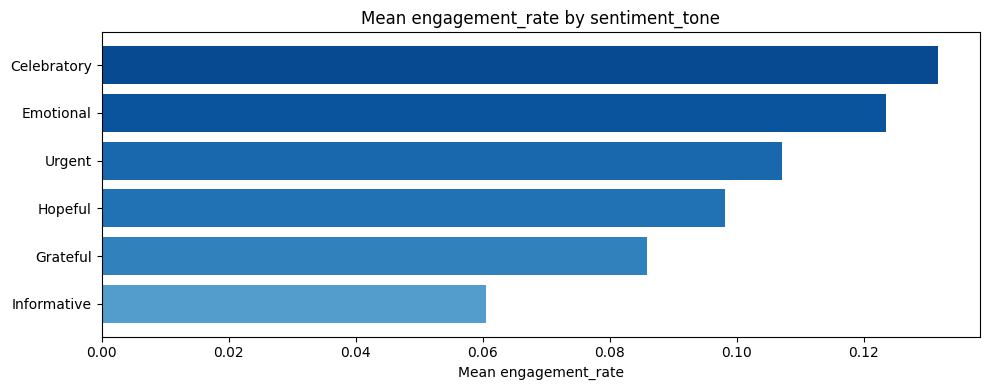

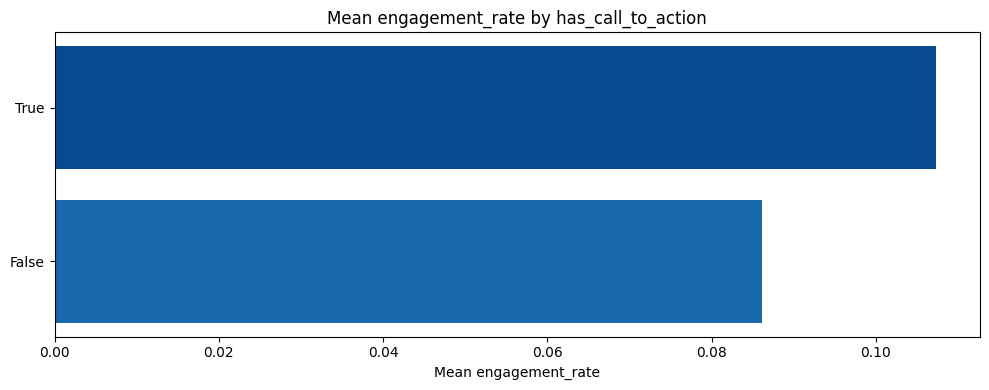

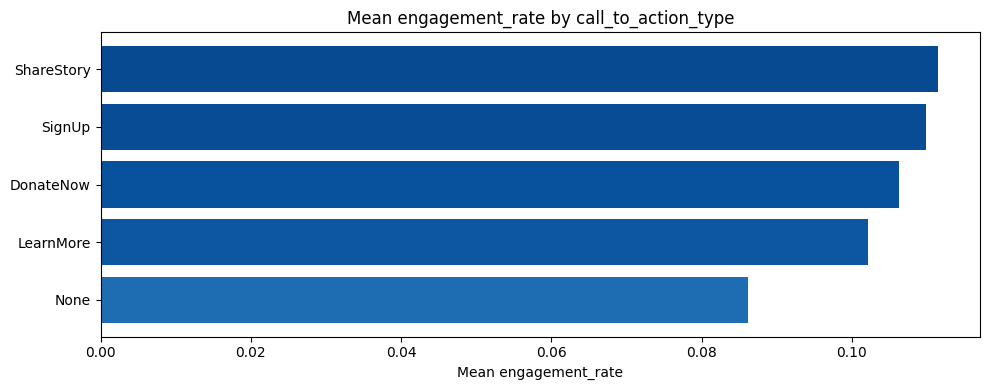

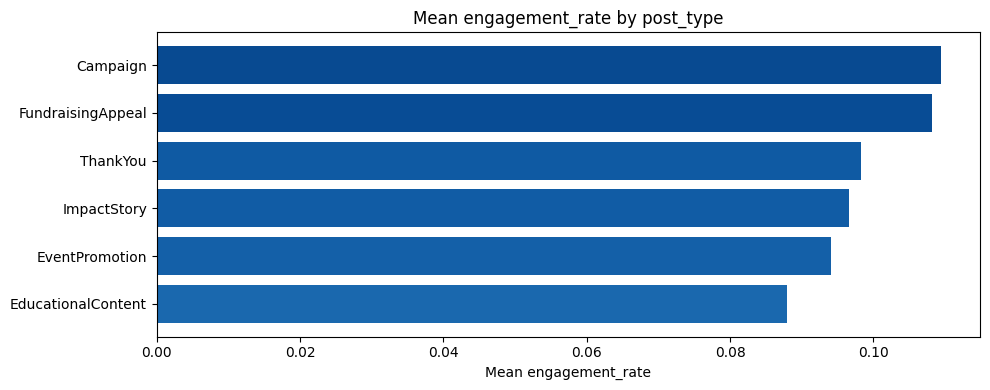

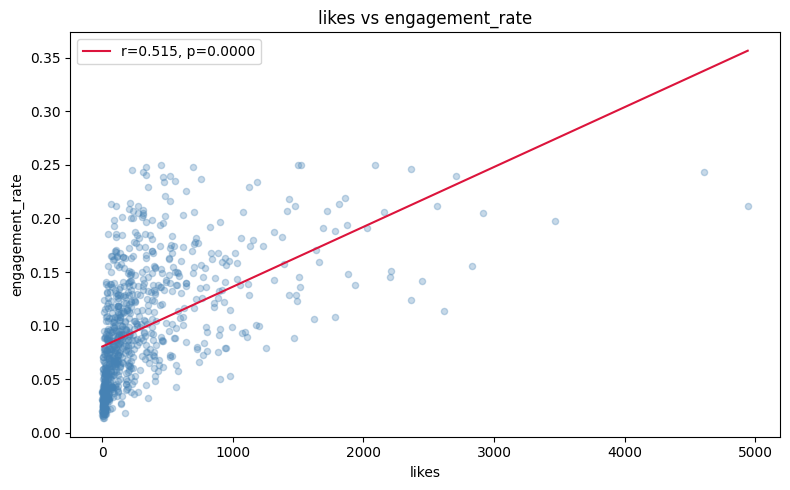

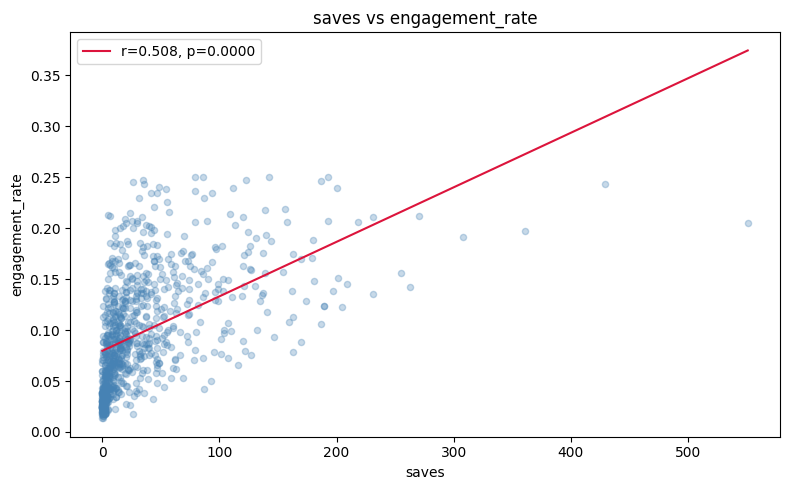

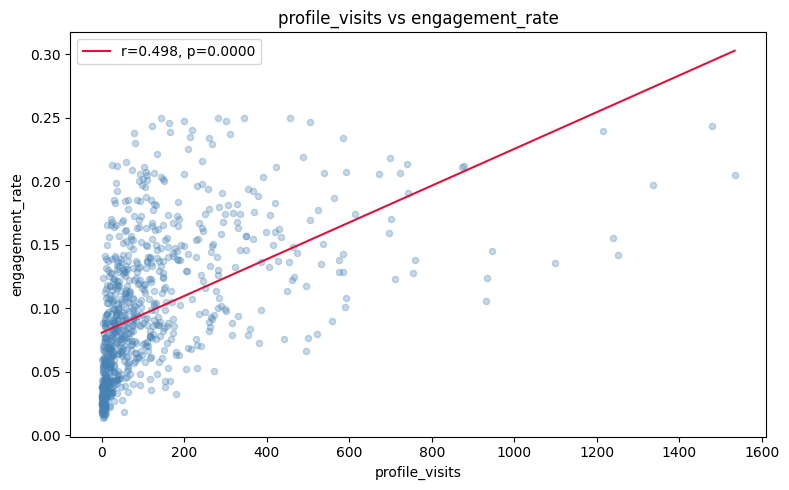

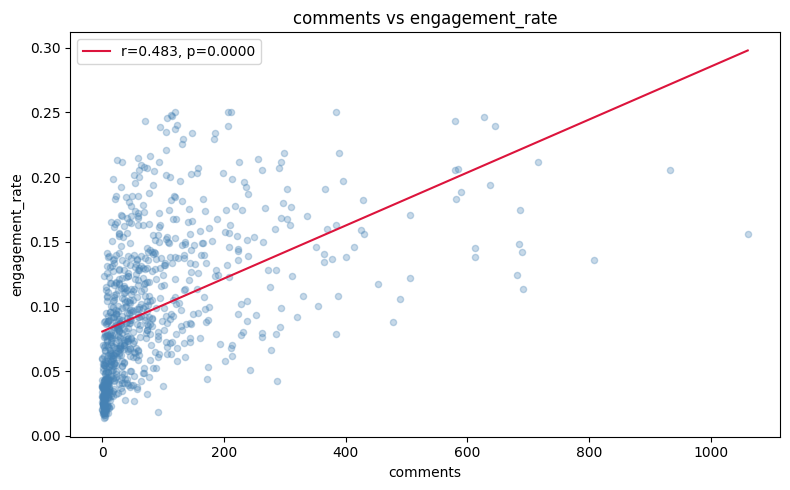

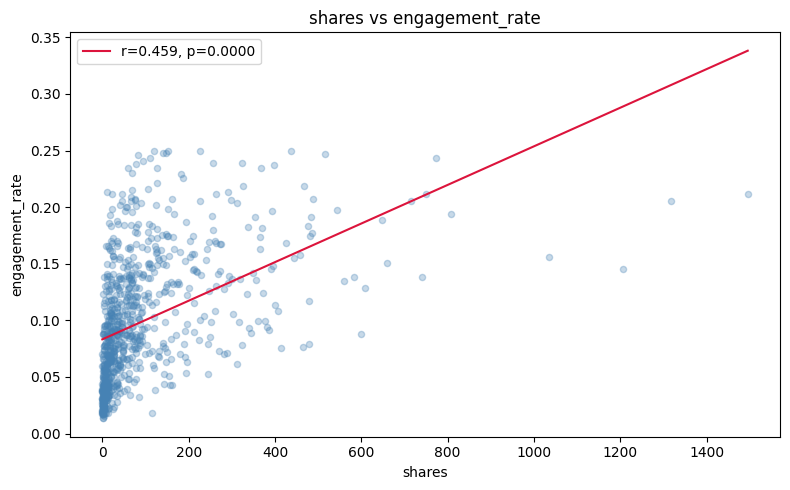

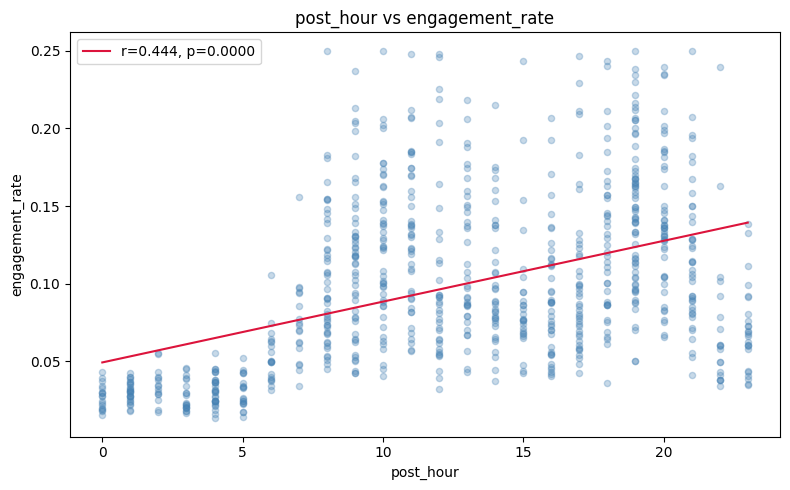

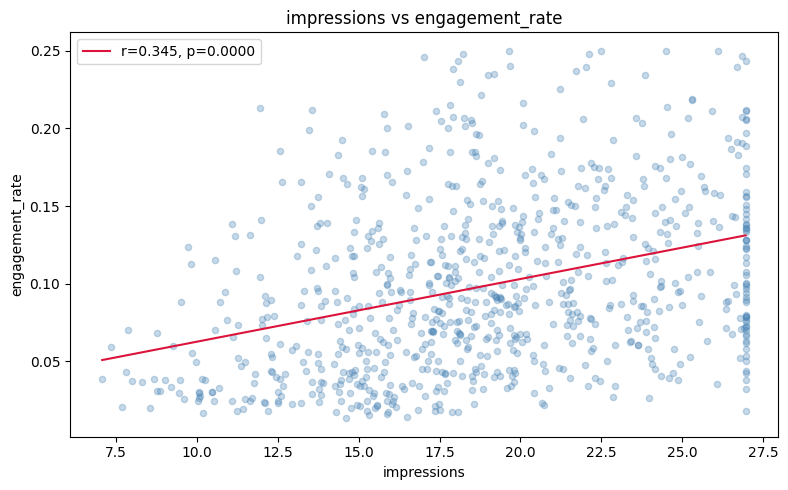

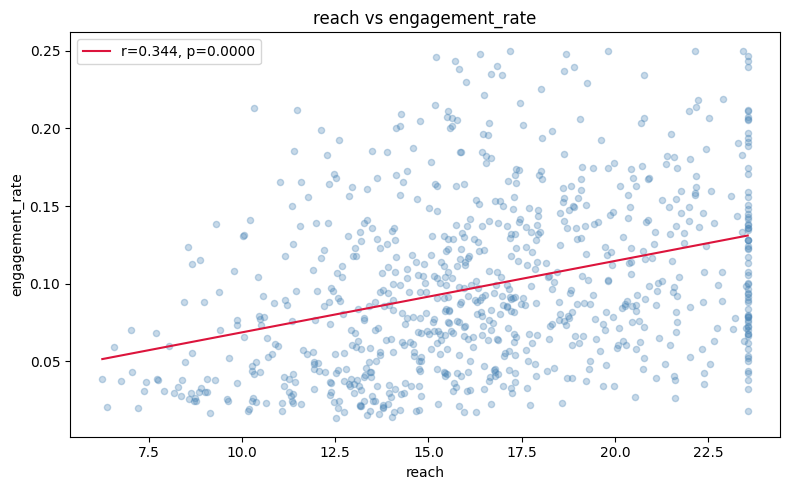

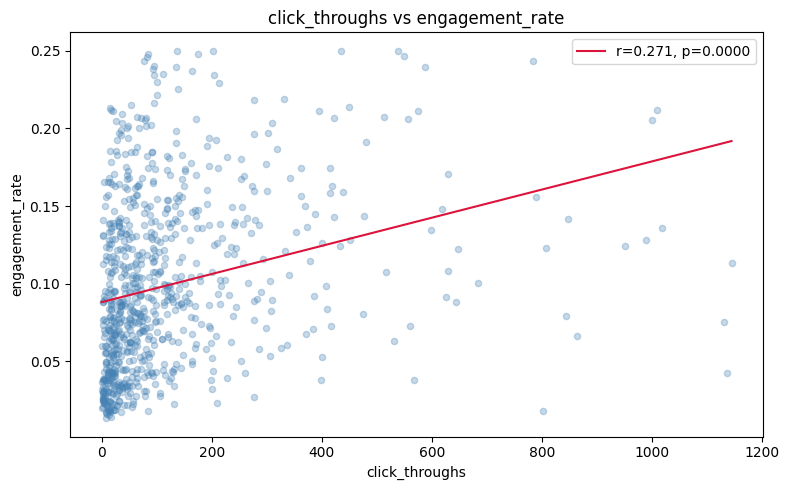

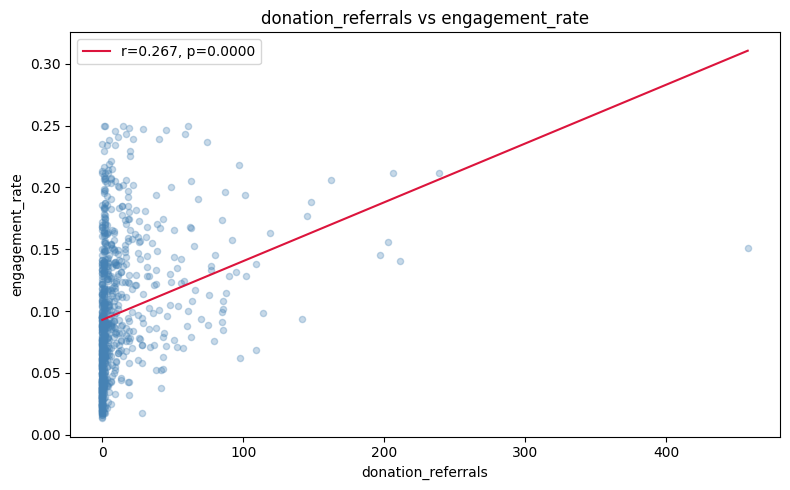

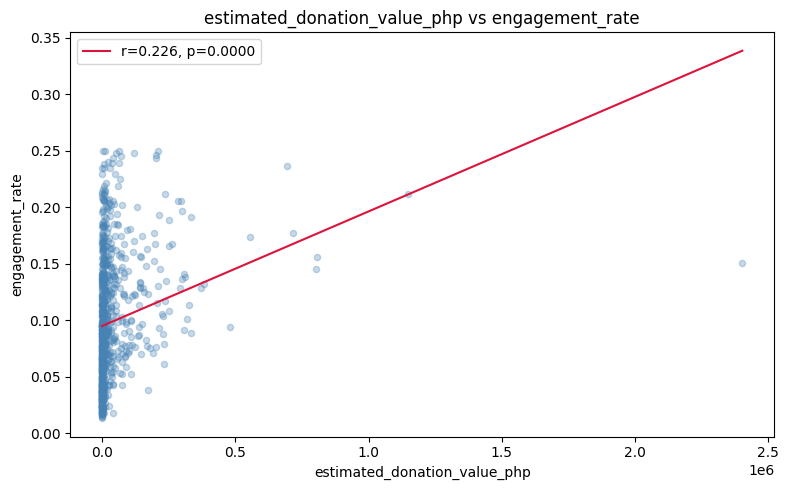

In [53]:
# Now the fun part. Run the full bivariate sweep against engagement_rate.
# This tells you which features are statistically significant predictors
# and shows you what the relationships actually look like.
#
# Read the printed ranking table carefully:
#   - High |r| numeric features → strong linear relationship → good for MLR
#   - High F categorical features → group means differ significantly
#   - Low p-value → statistically significant (not just noise)
#
# This directly informs which columns go into NUMERIC_FEATURES vs
# CATEGORICAL_FEATURES in fn_prepare.define_features()

plot_bivariate_summary(df, target='engagement_rate', top_n=15)

## Donation Referrals (Regression Target)


  BIVARIATE SUMMARY — target: 'donation_referrals'


  TOP FEATURES FOR 'donation_referrals' (p < 0.05)
                     feature    test       metric  p_value
     features_resident_story   ANOVA F = 212.6329 0.000000
                   post_type   ANOVA  F = 42.9329 0.000000
                  is_boosted   ANOVA  F = 12.4545 0.000440
               campaign_name   ANOVA   F = 6.8722 0.000019
                    platform   ANOVA   F = 5.2877 0.000023
              sentiment_tone   ANOVA   F = 3.7487 0.002317
                  media_type   ANOVA   F = 3.2163 0.012404
estimated_donation_value_php Pearson   r = 0.8918 0.000000
                      shares Pearson   r = 0.7272 0.000000
                    forwards Pearson   r = 0.5837 0.000000
                       likes Pearson   r = 0.5532 0.000000
                    comments Pearson   r = 0.5087 0.000000
                       saves Pearson   r = 0.5041 0.000000
              profile_visits Pearson   r = 0.4696 0.000000
          

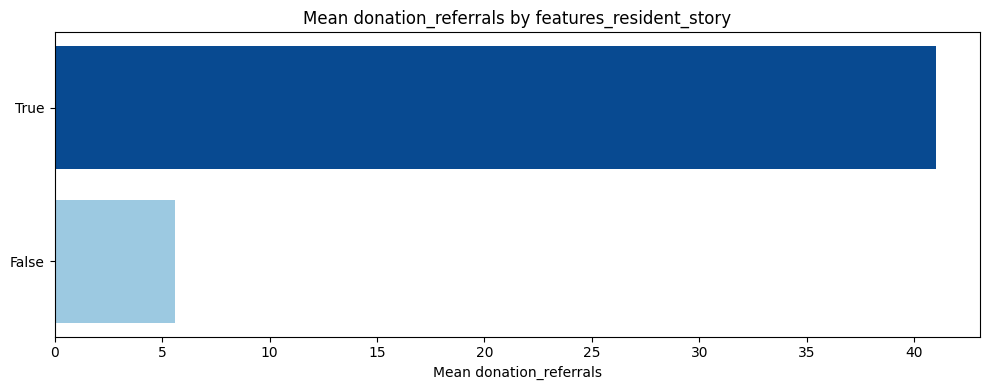

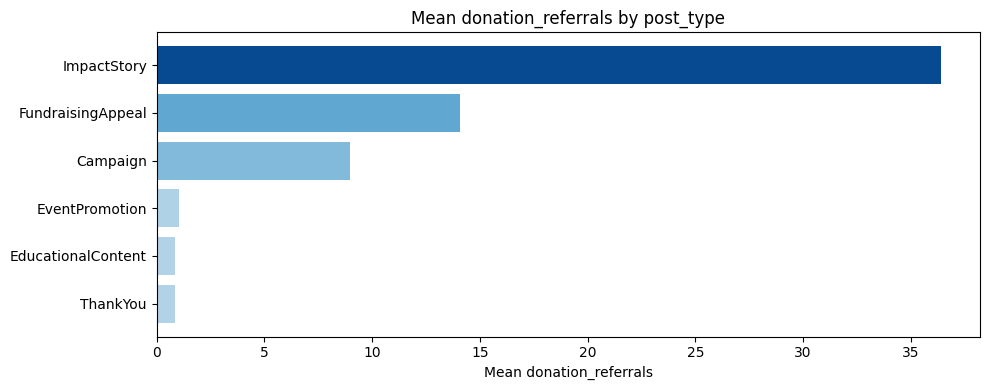

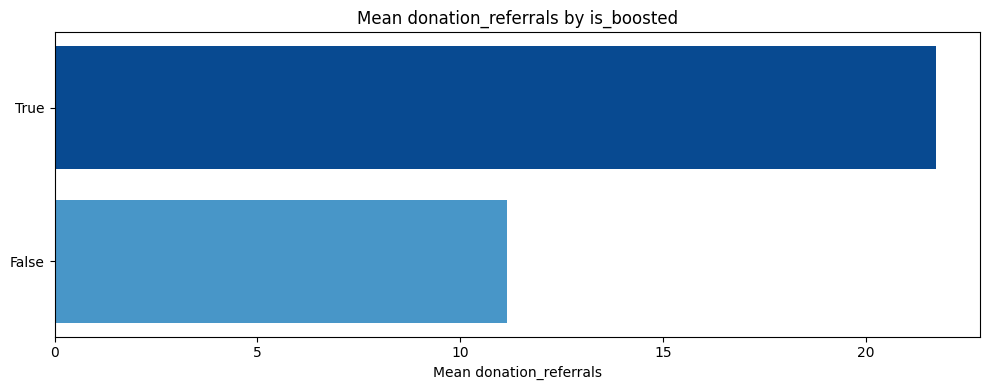

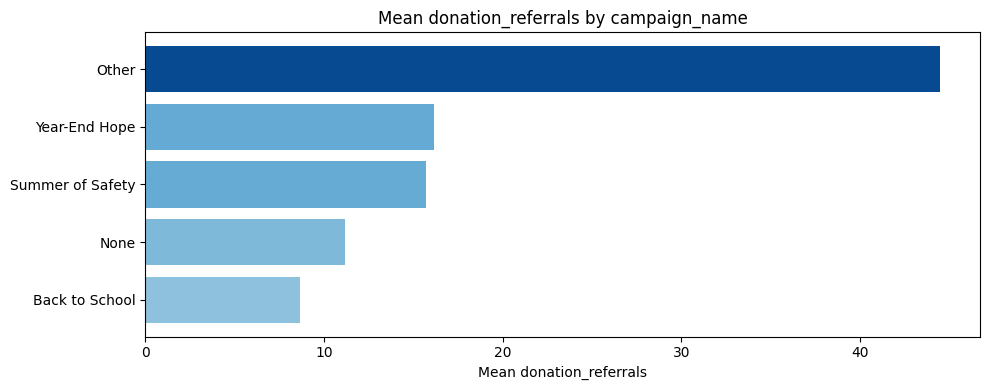

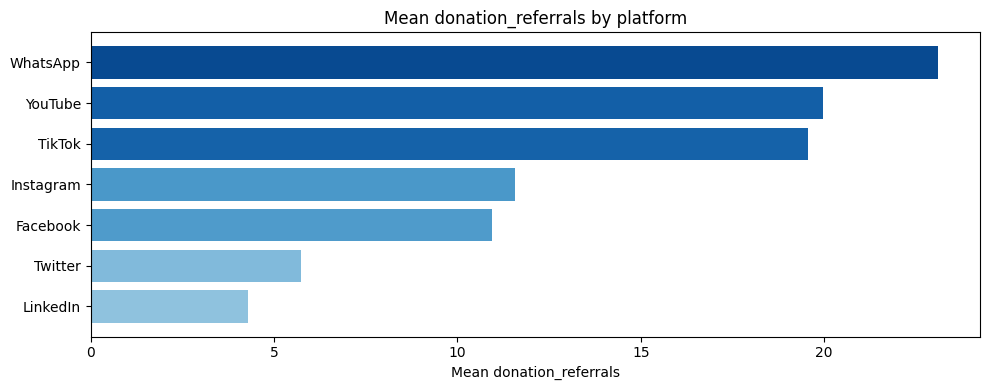

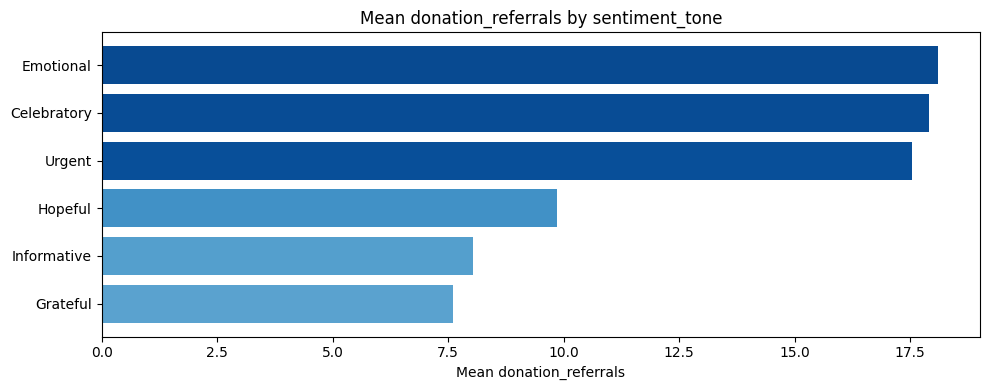

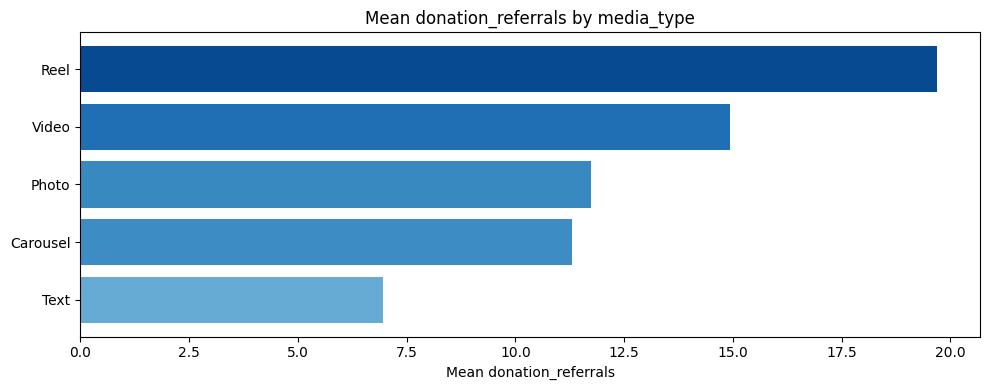

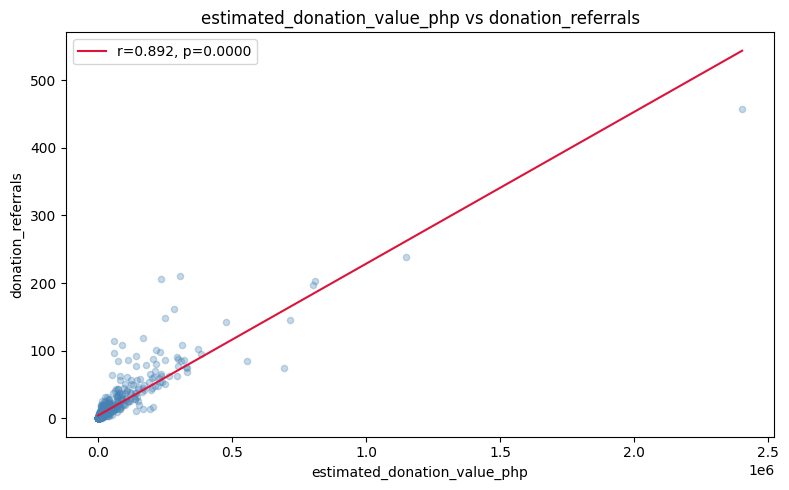

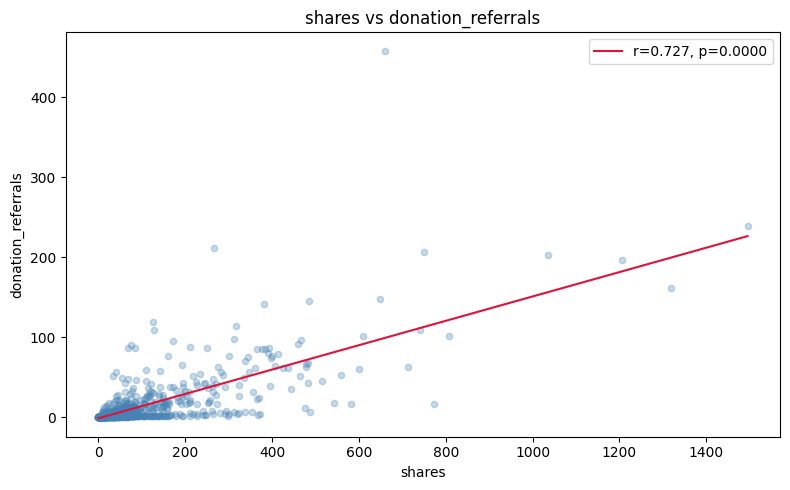

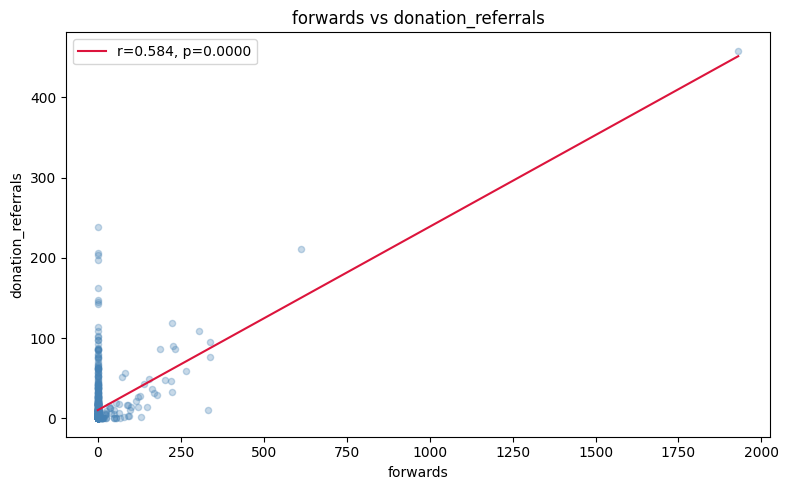

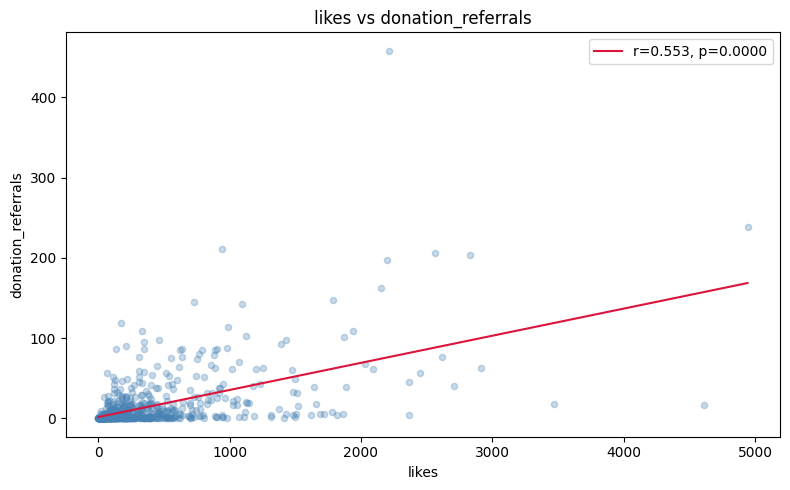

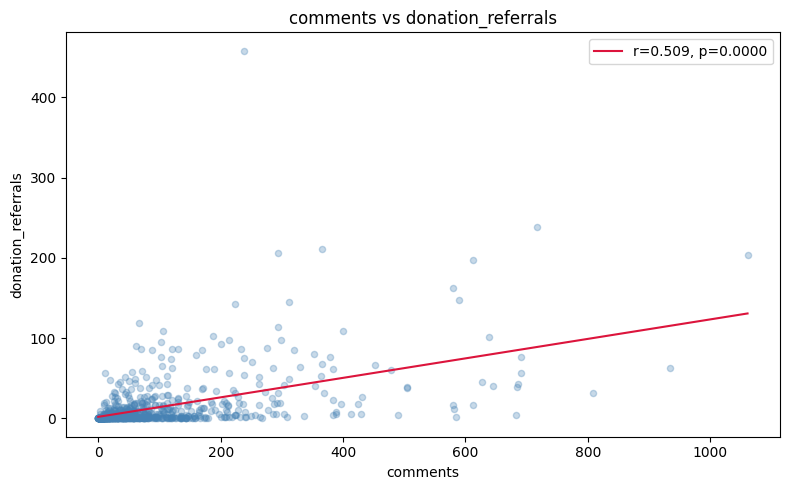

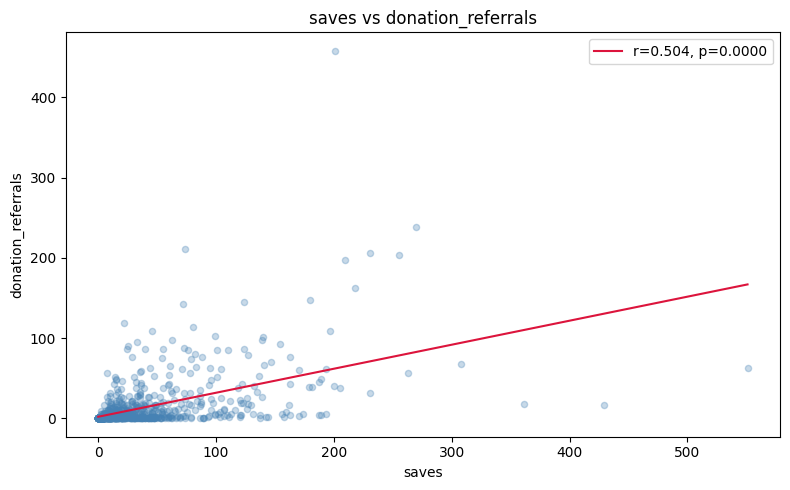

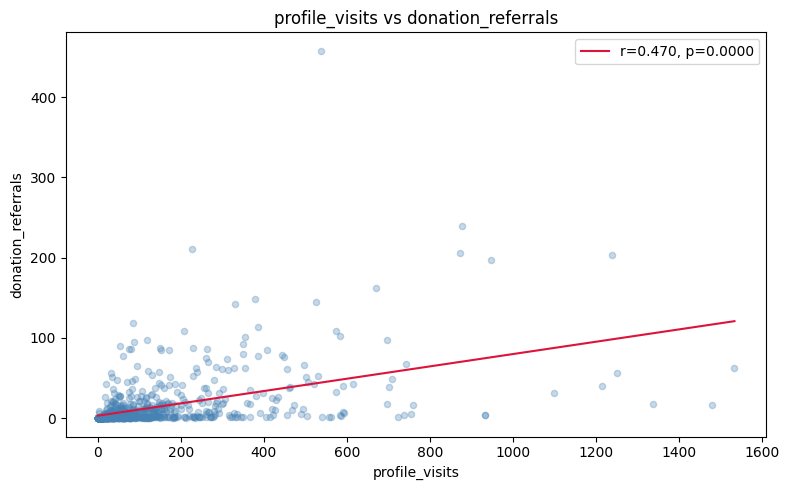

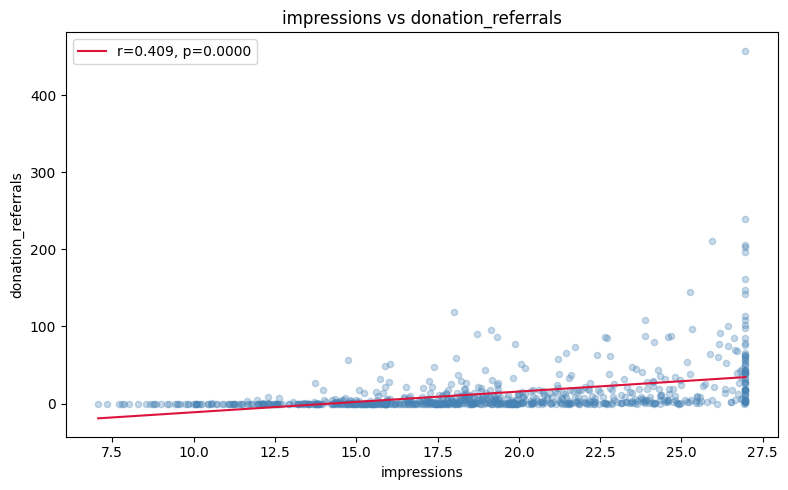

In [54]:
# Same sweep but for donation_referrals.
# Compare the results to Cell 21 — the features that matter for engagement
# may be completely different from those that matter for donations.
# That difference IS the insight your causal pipeline will quantify.

plot_bivariate_summary(df, target='donation_referrals', top_n=15)

## Led to Donation (Classification Target)


  BIVARIATE SUMMARY — target: 'led_to_donation'


  TOP FEATURES FOR 'led_to_donation' (p < 0.05)
                     feature    test      metric  p_value
     features_resident_story   ANOVA F = 16.8914 0.000044
                   post_type   ANOVA  F = 4.6332 0.000356
    confirmed_donation_count Pearson  r = 0.8973 0.000000
    confirmed_monetary_value Pearson  r = 0.6711 0.000000
                      shares Pearson  r = 0.1617 0.000004
          donation_referrals Pearson  r = 0.1571 0.000007
                       saves Pearson  r = 0.1545 0.000010
                    comments Pearson  r = 0.1516 0.000014
                       likes Pearson  r = 0.1390 0.000071
                       reach Pearson  r = 0.1359 0.000102
                 impressions Pearson  r = 0.1314 0.000173
              profile_visits Pearson  r = 0.1236 0.000415
             engagement_rate Pearson  r = 0.1225 0.000466
estimated_donation_value_php Pearson  r = 0.1109 0.001551
              click_throughs Pe

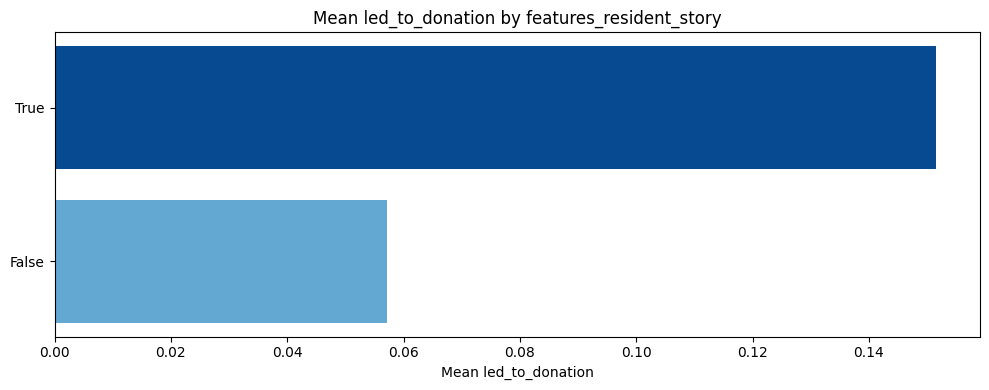

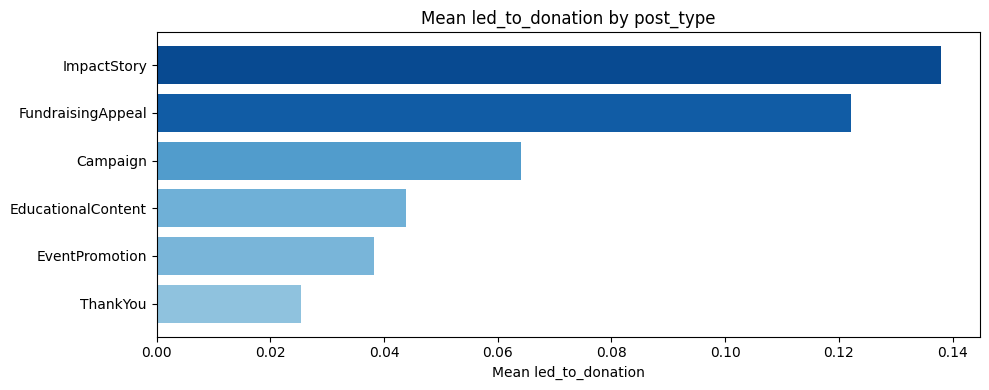

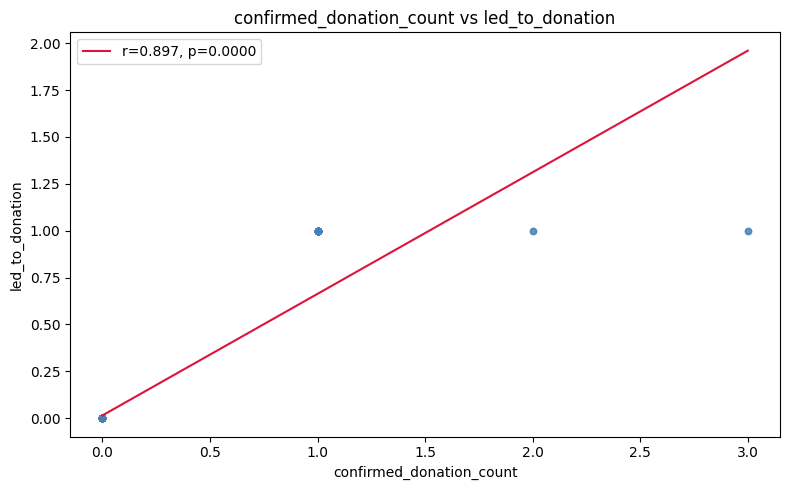

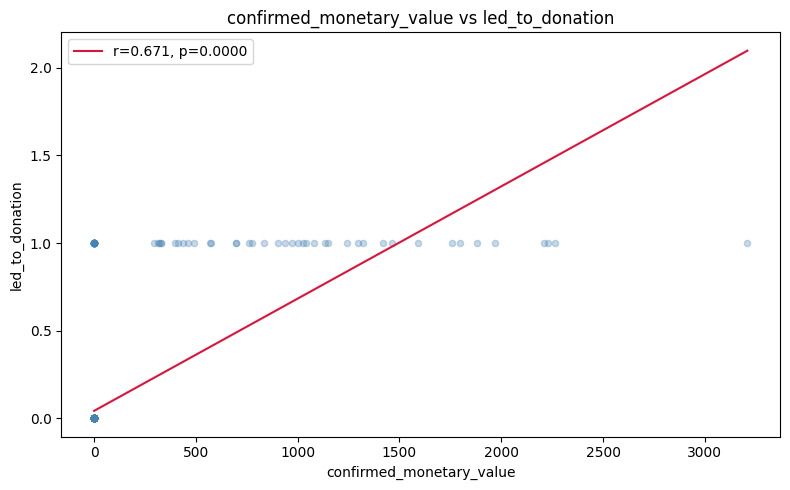

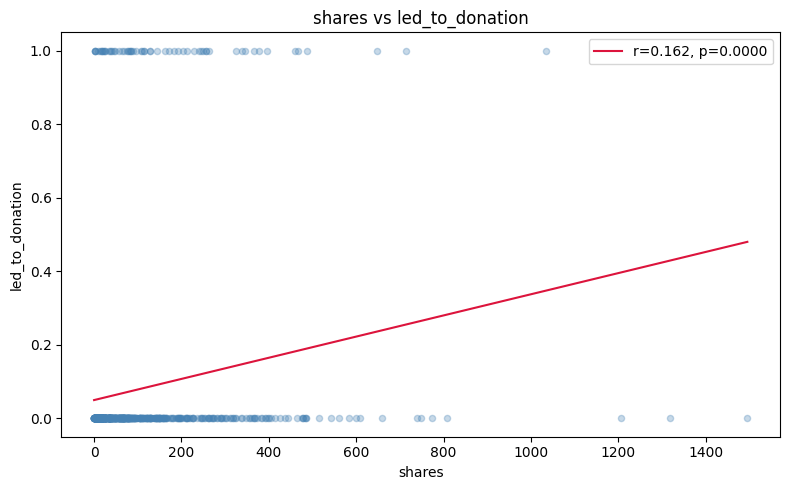

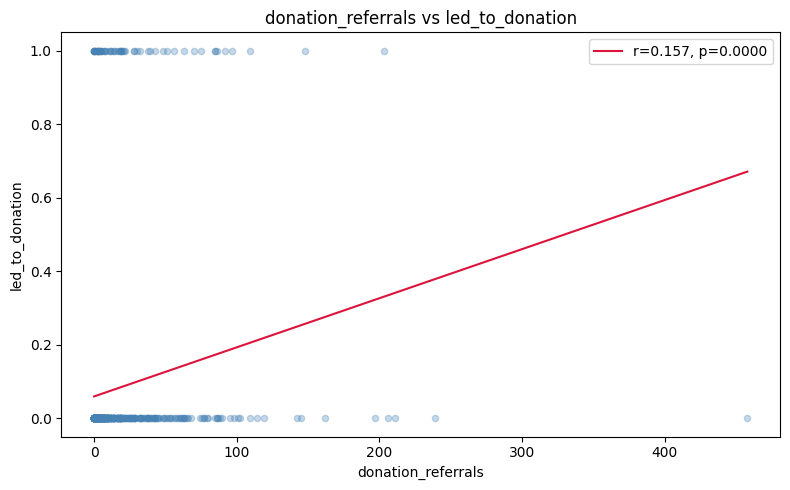

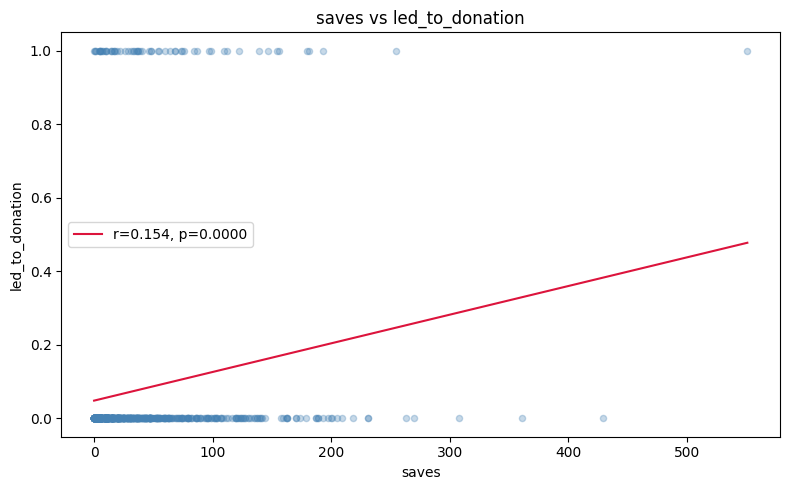

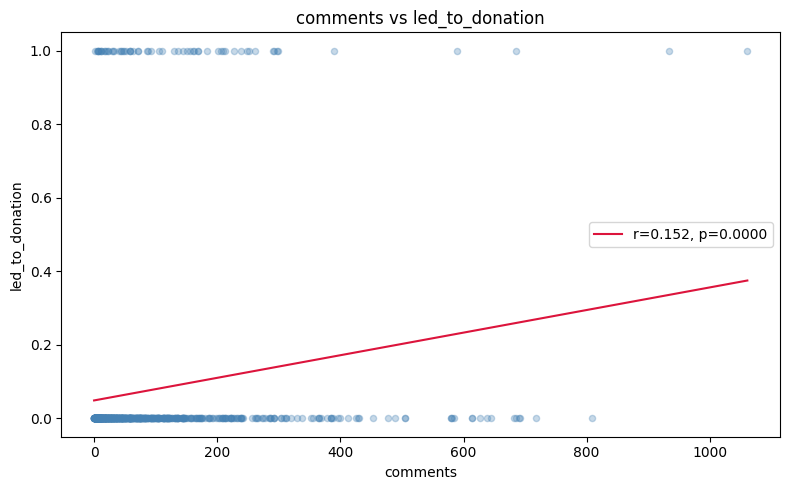

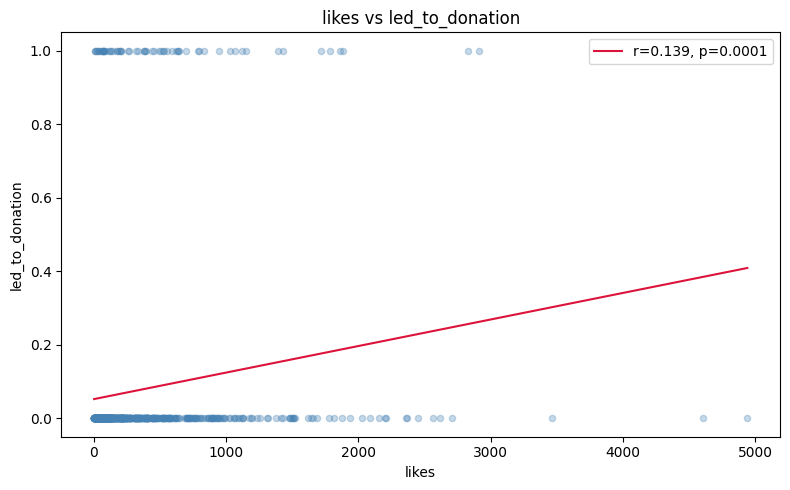

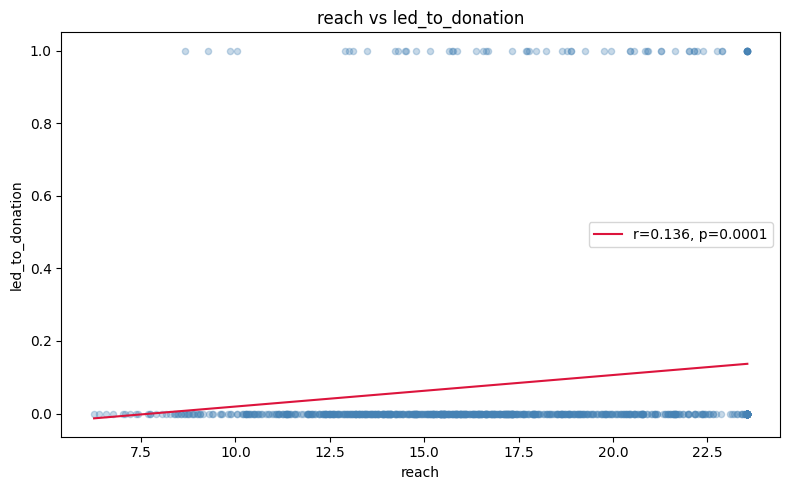

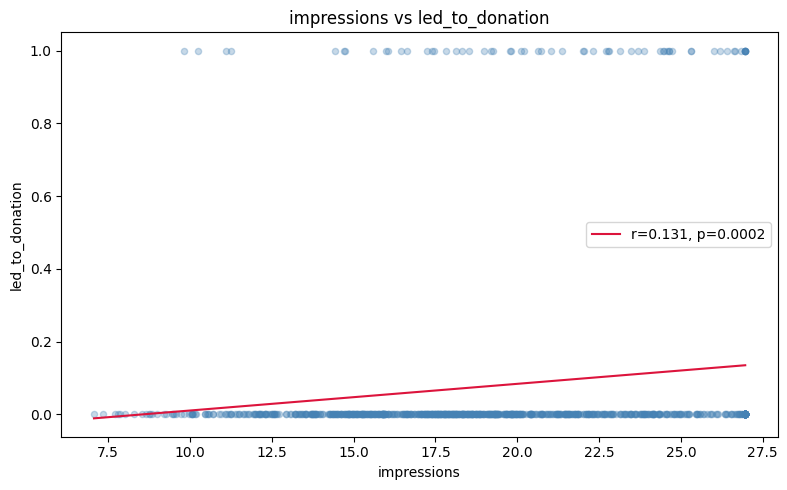

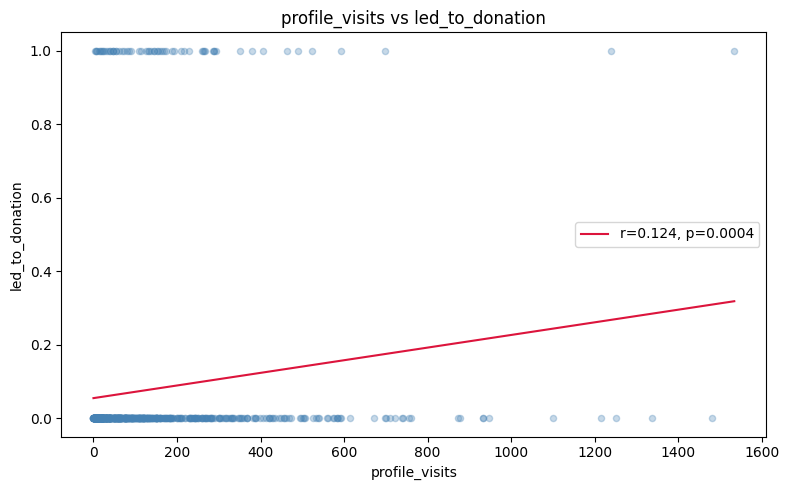

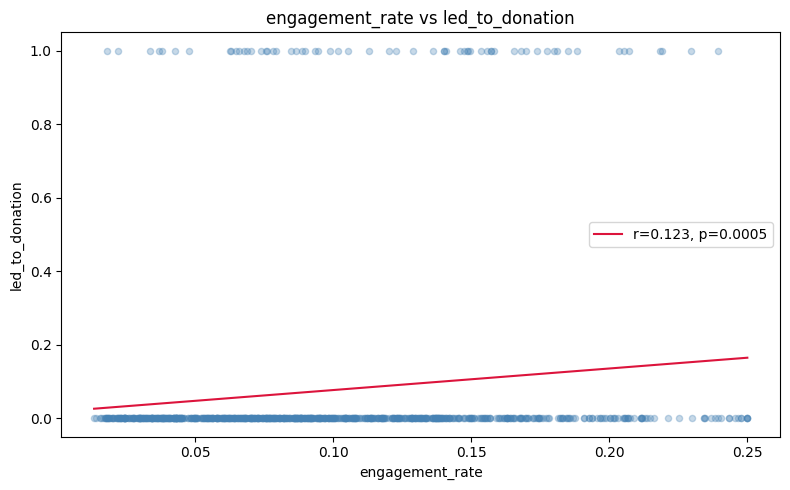

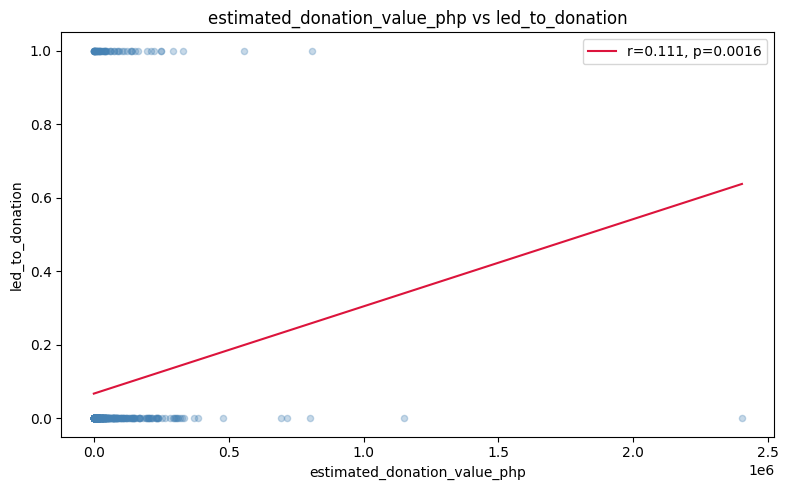

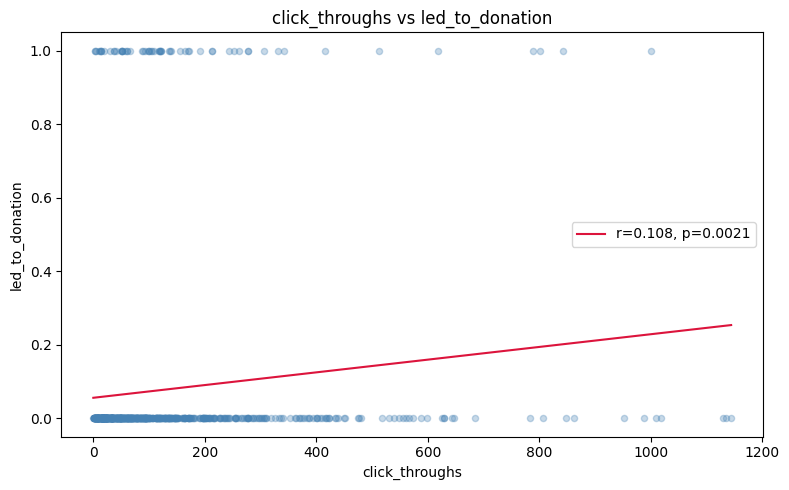

In [55]:
# Same sweep for the binary classification target.
# Because it's binary (0/1), the target rate charts (bar charts by category)
# are especially readable — you'll see which platforms, post types, and
# sentiment tones have the highest donation conversion rates.

plot_bivariate_summary(df, target='led_to_donation', top_n=15)

## Multicollinearity Check

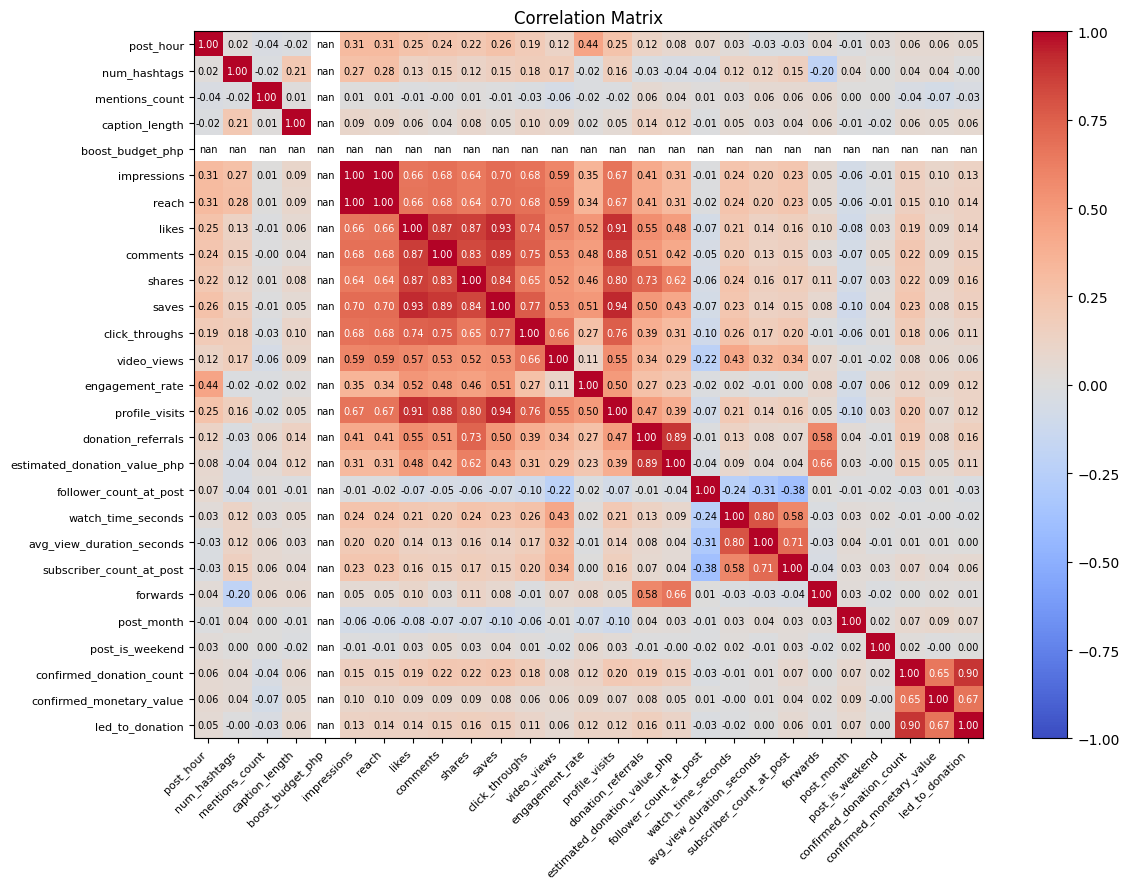

In [56]:
# Before finalizing your feature lists, check for multicollinearity:
# features that are so correlated with each other that including both
# adds no information (and destabilizes MLR coefficients).
#
# High |r| between TARGET and a feature → good, that's signal.
# High |r| between two FEATURES → potential multicollinearity problem.
#
# Expected high-correlation pairs to watch for:
#   likes/comments/shares vs engagement_rate (they literally compute it)
#   impressions vs reach (both measure audience size)
#   follower_count vs impressions (more followers = more impressions)
#
# Those first three (likes, comments, shares) MUST be in drop_cols
# when defining features for the engagement_rate regression —
# they are how engagement_rate is calculated. That's leakage.

numeric_cols = [c for c in df.select_dtypes(include='number').columns]
plot_correlation_heatmap(df, columns=numeric_cols)

In [57]:
# Print pairs above 0.7 threshold for easy reading
corr = get_correlation_matrix(df, columns=numeric_cols, threshold=0.7)


[get_correlation_matrix] Pairs with |r| > 0.7:
  impressions ↔ reach: r = 0.9965
  reach ↔ saves: r = 0.7002
  likes ↔ comments: r = 0.8707
  likes ↔ shares: r = 0.8654
  likes ↔ saves: r = 0.9257
  likes ↔ click_throughs: r = 0.7377
  likes ↔ profile_visits: r = 0.9078
  comments ↔ shares: r = 0.8309
  comments ↔ saves: r = 0.8873
  comments ↔ click_throughs: r = 0.7516
  comments ↔ profile_visits: r = 0.8775
  shares ↔ saves: r = 0.8365
  shares ↔ profile_visits: r = 0.8047
  shares ↔ donation_referrals: r = 0.7272
  saves ↔ click_throughs: r = 0.7652
  saves ↔ profile_visits: r = 0.9360
  click_throughs ↔ profile_visits: r = 0.7568
  donation_referrals ↔ estimated_donation_value_php: r = 0.8918
  watch_time_seconds ↔ avg_view_duration_seconds: r = 0.7962
  avg_view_duration_seconds ↔ subscriber_count_at_post: r = 0.7096
  confirmed_donation_count ↔ led_to_donation: r = 0.8973


# Confirm Feature Lists and Document Decisions

In [58]:
# Based on your EDA above, define your feature lists for each pipeline.
# These will be imported or copy-pasted into your pipeline notebooks.
# Document your reasoning here — this is your "Data Preparation report."

# ── Shared features (used in both regression pipelines) ──────────────────────
NUMERIC_FEATURES = [
    'num_hashtags',
    'mentions_count',
    'caption_length',
    'post_hour',
    'post_month',
    'post_is_weekend',
    'follower_count_at_post',
    'boost_budget_php',       # already transformed in Cell 16
    'video_views',            # 0 for non-video posts after Cell 10
    'forwards',               # 0 for non-WhatsApp posts after Cell 10
]

CATEGORICAL_FEATURES = [
    'platform',
    'post_type',
    'media_type',
    'day_of_week',
    'call_to_action_type',    # 'None' for posts with no CTA
    'content_topic',
    'sentiment_tone',
    'campaign_name',          # 'None' for unlinked posts
    'has_call_to_action',     # boolean → encoded as 0/1
    'is_boosted',             # boolean → encoded as 0/1
    'features_resident_story', # boolean → encoded as 0/1
]

# ── Drop cols: columns that must NEVER enter any of these models ──────────────
# These are either leaky (computed from the target) or identifiers.
DROP_ALWAYS = [
    # Leaky for engagement_rate regression:
    'likes', 'comments', 'shares', 'saves',
    'reach', 'impressions',          # engagement_rate = (likes+comments+shares)/reach
    'click_throughs', 'profile_visits',
    # Leaky for donation targets:
    'donation_referrals',
    'estimated_donation_value_php',
    'confirmed_donation_count',
    'confirmed_monetary_value',
    # Always drop:
    'platform_post_id',  # already dropped in Cell 7, listed here for clarity
]

print("Feature lists defined. Copy these into your pipeline notebooks.")
print(f"  Numeric:     {len(NUMERIC_FEATURES)} features")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)} features")
print(f"  Always drop: {len(DROP_ALWAYS)} columns")

Feature lists defined. Copy these into your pipeline notebooks.
  Numeric:     10 features
  Categorical: 11 features
  Always drop: 13 columns


## Save the Cleaned DataFrame

In [59]:
# Save df as a CSV so your pipeline notebooks can load it directly
# without repeating all the cleaning steps above.
# This is your "clean" dataset — the output of the Data Preparation phase.

df.to_csv('data/social_media_clean.csv', index=False)
print(f"Saved: data/social_media_clean.csv  ({df.shape[0]} rows × {df.shape[1]} cols)")

Saved: data/social_media_clean.csv  (812 rows × 38 cols)


## EDA Summary

In [60]:
summary = """
=== SOCIAL MEDIA EDA SUMMARY ===

Shape: 812 rows × 38 columns (after cleaning)
Date range: 2023-01-05 → 2024-12-xx (approx. 2 years)
Platforms: Facebook, Instagram, Twitter, WhatsApp, TikTok, LinkedIn, YouTube

INTENTIONAL NULLS HANDLED:
  - video_views → 0 for non-Video/Reel posts (479 filled)
  - watch_time_seconds → 0 for non-YouTube posts (741 filled)
  - avg_view_duration_seconds → 0 for non-YouTube posts (741 filled)
  - subscriber_count_at_post → 0 for non-YouTube posts (741 filled)
  - boost_budget_php → 0 when is_boosted is False (685 filled)
  - forwards → 0 for non-WhatsApp posts (719 filled)
  - call_to_action_type → 'None' when has_call_to_action is False (319 filled)
  - campaign_name → 'None' when no campaign (580 filled)

SKEWED COLUMNS TRANSFORMED:
  - impressions: yeo-johnson applied (skew: 1.159 → 0.045)
  - reach: yeo-johnson applied (skew: 1.170 → 0.042)
  - boost_budget_php: NOT transformed — 84% of values were 0 after null fill,
    causing IQR fences to collapse to [0, 0] and zero out all boosted values.
    DECISION: Drop boost_budget_php from NUMERIC_FEATURES. Use is_boosted
    (boolean, already in CATEGORICAL_FEATURES) to capture boosting signal.

RARE CATEGORIES BINNED:
  - campaign_name: 'GivingTuesday' (2.7%) → 'Other'
  - call_to_action_type: no rare categories found at 5% threshold

TARGET BASE RATES:
  - engagement_rate mean: 0.099 (about 10% of viewers interact per post)
  - donation_referrals mean: 12.8 (median: 2 — heavily right-skewed)
  - led_to_donation rate: 7.6% of posts (62 of 812) led to a confirmed donation
    ⚠️  Class imbalance — classification pipeline must use class_weight='balanced'

TOP FEATURES FOR ENGAGEMENT (from bivariate summary):
  1. sentiment_tone       (ANOVA F=37.75) — tone matters more than anything else
  2. has_call_to_action   (ANOVA F=29.14) — asking people to act drives engagement
  3. call_to_action_type  (ANOVA F=7.83)  — type of CTA also matters
  4. post_hour            (r=0.44)        — timing has a real effect

TOP FEATURES FOR DONATIONS (from bivariate summary):
  1. features_resident_story (ANOVA F=212.6) — by far the strongest signal
  2. post_type               (ANOVA F=42.9)  — FundraisingAppeal posts convert
  3. is_boosted              (ANOVA F=12.5)  — paid promotion helps donations
  4. forwards                (r=0.58)        — WhatsApp forwards drive real money

ENGAGEMENT vs DONATION INSIGHT:
  Different features drive each target. Sentiment tone and CTAs drive engagement.
  Resident stories and post type drive donations. A post optimized for likes
  is NOT the same as a post optimized for donations. This is the core finding
  the causal MLR pipeline will quantify with coefficients.

MULTICOLLINEARITY CONCERNS:
  - impressions ↔ reach: r=0.9965 (nearly identical — both dropped as leaky anyway)
  - likes ↔ saves: r=0.93, likes ↔ profile_visits: r=0.91 (all leaky, all dropped)
  - The entire engagement metric cluster (likes, comments, shares, saves,
    click_throughs, profile_visits) is highly intercorrelated — all dropped
    as leaky since they are components of or correlated with engagement_rate
  - watch_time_seconds ↔ avg_view_duration_seconds: r=0.80 (YouTube only,
    low variance after 0-fill — low expected signal)

LEAKY COLUMNS (in DROP_ALWAYS):
  - likes, comments, shares, saves → literally compute engagement_rate
  - reach, impressions → denominator/scale of engagement_rate
  - click_throughs, profile_visits → post-outcome metrics
  - donation_referrals, estimated_donation_value_php → are the donation targets
  - confirmed_donation_count, confirmed_monetary_value → are the donation targets

FINAL FEATURE LISTS:
  NUMERIC (9):  num_hashtags, mentions_count, caption_length, post_hour,
                post_month, post_is_weekend, follower_count_at_post,
                video_views, forwards
  CATEGORICAL (11): platform, post_type, media_type, day_of_week,
                    call_to_action_type, content_topic, sentiment_tone,
                    campaign_name, has_call_to_action, is_boosted,
                    features_resident_story

NOTES / SURPRISES:
  - features_resident_story is the single most powerful predictor of donations
    (F=212.6) — a clear, actionable finding for Hearth Haven leadership.
    Telling resident stories in posts drives 10x+ more donation activity.
  - Only 7.6% of posts led to any confirmed donation — the classification
    target is heavily imbalanced. Handle with class_weight='balanced'.
  - boost_budget_php was effectively destroyed by IQR capping (84% zeros).
    is_boosted captures the signal cleanly without this problem.
  - YouTube metrics (watch_time, avg_view_duration, subscriber_count) were
    0-filled for 89% of posts. Low expected contribution to models.
  - WhatsApp forwards (r=0.58 with donation_referrals) suggests WhatsApp
    is a high-conversion channel worth investigating separately.
"""

print(summary)


=== SOCIAL MEDIA EDA SUMMARY ===

Shape: 812 rows × 38 columns (after cleaning)
Date range: 2023-01-05 → 2024-12-xx (approx. 2 years)
Platforms: Facebook, Instagram, Twitter, WhatsApp, TikTok, LinkedIn, YouTube

INTENTIONAL NULLS HANDLED:
  - video_views → 0 for non-Video/Reel posts (479 filled)
  - watch_time_seconds → 0 for non-YouTube posts (741 filled)
  - avg_view_duration_seconds → 0 for non-YouTube posts (741 filled)
  - subscriber_count_at_post → 0 for non-YouTube posts (741 filled)
  - boost_budget_php → 0 when is_boosted is False (685 filled)
  - forwards → 0 for non-WhatsApp posts (719 filled)
  - call_to_action_type → 'None' when has_call_to_action is False (319 filled)
  - campaign_name → 'None' when no campaign (580 filled)

SKEWED COLUMNS TRANSFORMED:
  - impressions: yeo-johnson applied (skew: 1.159 → 0.045)
  - reach: yeo-johnson applied (skew: 1.170 → 0.042)
  - boost_budget_php: NOT transformed — 84% of values were 0 after null fill,
    causing IQR fences to collap